# Relational Cognitive Map Learner (R-GCML)
### Combining *goal-directed sampling from cognitive maps* with *the relational bottleneck*, and applying the result to ARC-AGI

---

**Paper 1 — the methodology.**
Lin, Yang, Zhao, Pezzulo & Maass (2026), *Neural sampling from cognitive maps enables goal-directed imagination and planning*, **Nature Machine Intelligence 8:1045–1065**. Code: `LH-cbicr/GCML`, building on the CML of Stöckl, Yang & Maass (*Nat. Commun.* 15:2344, 2024).

**Paper 2 — the approach.**
Webb, Frankland, Altabaa, Segert, Krishnamurthy, Campbell, Russin, Giallanza, O'Reilly, Lafferty & Cohen (2024), *The relational bottleneck as an inductive bias for efficient abstraction*, **Trends in Cognitive Sciences 28(9):829–843**.

**Target.** ARC-AGI (https://arcprize.org/arc-agi).

---

## What this notebook is, and is not

It **is** a complete, runnable, dependency-free (NumPy-only, **zero backpropagation**) implementation of a system that combines both papers, together with the diagnostics and ablations needed to test whether the combination actually does what the theory says it should.

It is **not** a competitive ARC-AGI submission. A backprop-free model over a hand-built ~70-action DSL will solve the fraction of ARC that lies inside that DSL's reach, and no more. Chollet's benchmark is deliberately built to defeat exactly this kind of fixed-primitive search. The scientific content here is in the **controlled comparisons**, which are stated as falsifiable predictions in §3 and answered in §11–§13.

Your initial instinct — that these two papers are both relevant to ARC — is, I think, right, and for a sharper reason than "both are about abstraction": *each one repairs the other's specific, identifiable failure on this task.* §3 makes that argument precisely.

---
# 1. What each paper actually says

## 1.1 GCML — a cognitive map you can plan in with one matrix–vector product

A **cognitive map** here is a pair of learned linear embeddings into a common high-dimensional space:

$$\mathbf{s}_t = \mathbf{Q}\mathbf{o}_t \qquad (8)$$

$$\hat{\mathbf{s}}_{t+1} = \mathbf{Q}\mathbf{o}_t + \mathbf{V}\mathbf{a}_t \qquad (10)$$

$\mathbf{Q}$ embeds observations, $\mathbf{V}$ embeds actions, and learning simply drives the **prediction error** $\mathbf{s}_{t+1}-\hat{\mathbf{s}}_{t+1}$ to zero using delta rules:

$$\Delta\mathbf{V} = \eta_v(\mathbf{s}_{t+1}-\hat{\mathbf{s}}_{t+1})\mathbf{a}_t^{\!\top} \qquad (12)$$
$$\Delta\mathbf{Q} = \eta_q(\hat{\mathbf{s}}_{t+1}-\mathbf{s}_{t+1})\mathbf{o}^{\!\top} \qquad (13)$$

The consequential piece is the **inverse model** $\mathbf{W}$, which maps *state differences* back onto the actions that caused them:

$$\Delta\mathbf{W} = \eta_w\,\mathbf{a}_t(\mathbf{s}_{t+1}-\mathbf{s}_t)^{\!\top} \qquad (14)$$

Because $\mathbf{W}$ is linear, a matrix trained only on **local, one-step** differences can be applied to the **global, many-step** difference to a distant goal:

$$\mathbf{u}_t = \mathbf{W}(\mathbf{s}^{*}-\hat{\mathbf{s}}_t) \qquad (16)$$

That is the *sense of direction*. Its cost does not grow with distance to the goal — one matrix–vector product, whether the goal is one step away or twenty. Action selection gates by affordance, injects noise, and takes a winner:

$$\mathbf{e}_t = \hat{\mathbf{g}}_t\odot(\mathbf{u}_t+\boldsymbol\epsilon)\quad(18)\qquad \mathbf{a}_t=\mathrm{WTA}(\mathbf{e}_t)\quad(19)\qquad \hat{\mathbf{s}}_{t+1}=\hat{\mathbf{s}}_t+\mathbf{V}\mathbf{a}_t\quad(20)$$

Eq. (20) is what makes it **G**enerative: during imagination no observations arrive, so the model's own forward prediction stands in for them. The noise $\boldsymbol\epsilon$ turns one deterministic plan into a *distribution over plans*, giving a menu of near-shortest solutions (their Fig. 3c–d) that a downstream criterion can then choose among (Fig. 3f).

## 1.2 The relational bottleneck — abstraction by *refusing to look at* object identity

Webb et al. define it (their Box 2) as any mechanism restricting the compressed representation passed downstream to a **relational signal**

$$R = \{\,r(x_i,x_j)\,\}_{i\neq j},\qquad r(x_i,x_j)=\langle \phi(x_i),\psi(x_j)\rangle$$

Downstream processing sees $R$ **and nothing else** — object-level features are discarded, not merely de-emphasised. Separate encoders $\phi\neq\psi$ make the relation asymmetric (the Abstractor's contribution), and recursion gives relations-between-relations.

The payoff is systematic generalisation to novel objects: the ESBN learns identity rules from as few as four examples and still generalises when 95 of 100 objects are withheld from training, where Transformers and LSTMs collapse (their Fig. 3A).

---
# 2. What the GCML repository shows that the paper does not

I read `GCML-main` before writing this notebook, and three things in the code materially changed the design. This is worth recording, because two of them contradict a natural reading of the paper.

### 2.1 In the compositional task, **Q is fixed and hand-designed — not learned**

The tiling notebook's encoder is a fixed convolution, with no learnable parameters:

```python
self.q_conv_.weight.data = torch.tensor([[[[0.,1.,0.],[1.,0.,1.],[0.,1.,0.]]]])

def Q_encoder(self, x):
    y = x.reshape((-1, 1, self.edge, self.edge))
    s = self.q_conv(1 - y)          # count empty/outside 4-neighbours
    s = s.reshape((-1, self.edge*self.edge))
    return s * x                    # ... at filled cells only
```

`Q_encoder` returns, for every filled cell, **how many of its four neighbours are empty or outside the grid** — an *exposed-edge* count. Only `V` and `W` are learned. This matches the paper's phrasing once you look for it ("a key step is that one makes the embedding **Q** ... compositional. The embedding **V** ... and the inverse model **W** are learned"), but the code makes unambiguous what the paper leaves implicit.

**Consequence for us.** The single most important design question — *what plays the role of Q for ARC?* — is answered: Q is where you inject domain structure, by hand, and it is not learned. **The relational bottleneck is our Q.** That is the joint on which the whole combination turns.

### 2.2 In the tiling task, W is **assigned**, and the resulting heuristic is interpretable

```python
model.W[action, :] = o_next - o_pre     # assignment, not accumulation
utility = model.W @ (0 - s_pre.T)
```

Since the goal is the empty silhouette, $\mathbf{s}^*=0$, and $\mathbf{W}[a] = -(\text{tile mask})$, the utility of removing tile $a$ works out to

$$u_a=\langle \text{tile mask}_a,\ \text{exposed-edge count}\rangle$$

— *peel tiles that sit on the boundary first*. A sensible greedy tiling heuristic, and the "sense of direction" in this domain is exactly that and nothing more. Useful calibration for what to expect on ARC.

### 2.3 In the graph task, W is learned by a **delta rule**, not the paper's Hebbian eq. (14)

```python
utility = model.W @ (s_next - s_pre)
model.W += 0.01 * (desired - utility) @ state_diff.T / batch_size
```

i.e. $\Delta\mathbf{W}=\eta(\mathbf{a}-\mathbf{W}\Delta\mathbf{s})\Delta\mathbf{s}^{\!\top}$, which is *not* eq. (14). We implement **both** and compare in §11. The result is a real domain effect, and it goes against the code: the delta rule wins when an action has a deterministic state-change signature (a graph edge always does), but ARC actions have strongly context-dependent effects, and there the Hebbian **prototype** is markedly more robust.

Also noted and adopted: noise is scaled by the current maximum utility (`randn_like(utility) * sigma * max(utility)`), affordances in the tiling task are **queried from the environment** rather than from the learned $\mathbf{G}$, and the tiling planner **executes each action for real** rather than bootstrapping — i.e. the compositional GCML is already *closed-loop*. Our solver follows all three.

---
# 3. The combination, and why ARC is the right test of it

## 3.1 Each paper repairs the other's specific failure

**GCML's failure on ARC.** $\mathbf{Q}$ embeds *concrete* observations. Every ARC task has its own colours, shapes and grid sizes, so a map learned on one task does not transfer to the next. The paper sidesteps this by hand-designing a compositional $\mathbf{Q}$ for silhouettes — but for ARC, *designing that encoder is the entire problem*. Left alone, GCML has a planner with nothing general to plan over.

**The relational bottleneck's failure on ARC.** ESBN, CoRelNet and the Abstractor are discriminative feed-forward maps. They classify a relation; they cannot compose a *sequence* of operations to reach a goal, and they have no notion of a goal at all. Left alone, the bottleneck has a general representation with nothing to do with it.

**Put them together.** Make the cognitive map's state space relational. Then a state means *"two objects alike, one left of the other"* rather than *"a blue 3×3 square at row 4"* — and the same map, and the same learned $\mathbf{W}$, apply to a task whose objects have never been seen. The bottleneck supplies GCML's missing compositional $\mathbf{Q}$; GCML supplies the bottleneck's missing sense of direction and its generative multi-step sampler.

This is not a strained pairing. The TiCS paper's own *Outstanding questions* ask: *"Can the relational bottleneck principle be usefully applied to symbolic (or neuro-symbolic) models...? Could program induction models benefit from a constraint that forces perceptual inputs to be recoded in terms of relations?"* This notebook is a concrete, testable answer.

## 3.2 The two ARC-specific moves

**(a) The goal is never given — it is implied.** In the paper's tasks the agent is handed $\mathbf{s}^*$. ARC hands you demonstration pairs. So we navigate **inside a demonstration**: for pair $(\text{in}_0,\text{out}_0)$ set $\mathbf{s}^*=\mathbf{Q}\,o(\text{out}_0)$ and $\mathbf{s}_0=\mathbf{Q}\,o(\text{in}_0)$. Because $o$ is relational, the route the map proposes for demo 0 is *stated in terms that survive transfer* to the test input, whose objects are different. **That transfer is the analogy, and the bottleneck is what supplies it.** Without it, this move is simply invalid.

**(b) ARC hands us something the graph tasks lack: a free exact verifier.** Any proposed program can be executed on every demonstration pair and checked for exact equality. So GCML becomes a **proposal distribution over programs**, and verification does the accepting. This is the paper's own Fig. 3f — "a downstream network could select from this repertoire of imagined trajectories based on a given criterion" — with *demonstration-consistency* as the criterion. It is also what makes the whole thing safe: a bad proposal costs a little compute, never a wrong answer.

## 3.3 Three falsifiable predictions

| # | Prediction | Tested in |
|---|---|---|
| **P1** | A relational state code is **invariant** to relabelling the palette; a feature-based code is not. This is the transfer mechanism, so it must hold exactly, not approximately. | §11.1 |
| **P2** | The map's sense of direction beats uninformed search **per unit of computational effort** — GCML's Fig. 6a/6b claim, in a new domain. | §12 |
| **P3** | Removing the bottleneck (raw colours + absolute positions, same everything else) degrades **transfer to unseen palettes** specifically, not in-distribution fit. | §13 |

P1 and P3 are the relational-bottleneck claims; P2 is the GCML claim. If P1 fails the combination is pointless; if P2 fails the map is dead weight; if P3 fails the bottleneck is doing nothing that whitening would not.

---
# 4. Setup

Pure NumPy. No PyTorch, no TensorFlow, **no backpropagation anywhere** — every weight update below is a delta rule or a Hebbian outer product, exactly as both the CML and GCML papers require for neuromorphic implementability. Runs on a free Colab CPU instance.

In [ ]:
import numpy as np, json, os, time, sys, urllib.request, zipfile, io, heapq, copy
from collections import Counter, deque, defaultdict
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True, linewidth=140)
RNG = np.random.default_rng(0)
print("numpy", np.__version__)

# ARC's canonical 10-colour palette, for plotting only.
ARC_CMAP = np.array([
    [0,0,0],[0,116,217],[255,65,54],[46,204,64],[255,220,0],
    [170,170,170],[240,18,190],[255,133,27],[127,219,255],[135,12,37]
], dtype=np.uint8)

def show_grid(g, ax=None, title=None):
    g = np.asarray(g)
    if ax is None:
        _, ax = plt.subplots(figsize=(2.2, 2.2))
    ax.imshow(ARC_CMAP[np.clip(g, 0, 9)], interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_color("#888")
    if title:
        ax.set_title(title, fontsize=8)
    return ax

def show_task(demos, test=None, maxpairs=4):
    n = min(len(demos), maxpairs) + (1 if test is not None else 0)
    fig, axs = plt.subplots(2, n, figsize=(1.8*n, 3.8))
    axs = np.atleast_2d(axs)
    for k, (gi, go) in enumerate(demos[:maxpairs]):
        show_grid(gi, axs[0, k], f"demo {k} in")
        show_grid(go, axs[1, k], "out")
    if test is not None:
        show_grid(test[0], axs[0, n-1], "TEST in")
        if test[1] is not None:
            show_grid(test[1], axs[1, n-1], "TEST out")
        else:
            axs[1, n-1].axis("off")
    plt.tight_layout(); plt.show()

numpy 2.0.2


---
# 5. ARC data

We try ARC-AGI-1 and ARC-AGI-2 from GitHub, and fall back to a built-in synthetic generator if the runtime has no network. **Everything below runs either way** — the synthetic tasks are used for the controlled experiments (§12–§13) regardless, because there we need to *know* the ground-truth program depth in order to measure search effort against it.

cloning ARC-AGI-1 ...
loaded ARC-AGI-1: eval=400, train=400

example task: 5 demos, test input (3, 3)


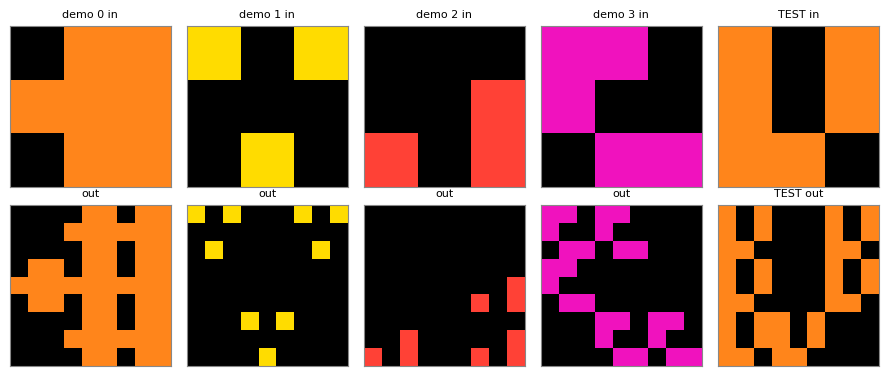

In [ ]:
def _try_clone(url, dest):
    try:
        import subprocess
        subprocess.run(["git","clone","--depth","1",url,dest],
                       check=True, capture_output=True, timeout=180)
        return True
    except Exception as e:
        print(f"  ! {url}: {type(e).__name__}")
        return False

def load_arc():
    '''Return {'train': [...], 'eval': [...]} of raw ARC task dicts, or empty on failure.'''
    for name, url in [("ARC-AGI-1","https://github.com/fchollet/ARC-AGI.git"),
                      ("ARC-AGI-2","https://github.com/arcprize/ARC-AGI-2.git")]:
        d = f"/content/{name}" if os.path.isdir("/content") else f"./{name}"
        if not os.path.isdir(d):
            print(f"cloning {name} ...")
            if not _try_clone(url, d):
                continue
        # locate the json folders wherever they live in the repo
        found = {}
        for root, _, files in os.walk(d):
            js = [f for f in files if f.endswith(".json")]
            if len(js) < 50:
                continue
            key = "train" if "train" in root.lower() else ("eval" if ("eval" in root.lower() or "valid" in root.lower()) else None)
            if key and key not in found:
                found[key] = [os.path.join(root, f) for f in sorted(js)]
        if found:
            out = {}
            for k, paths in found.items():
                out[k] = []
                for p in paths:
                    try:
                        out[k].append(json.load(open(p)))
                    except Exception:
                        pass
            print(f"loaded {name}: " + ", ".join(f"{k}={len(v)}" for k, v in out.items()))
            return out
    print("no ARC data available -- synthetic tasks only (all experiments still run)")
    return {}

ARC = load_arc()

def arc_to_task(t):
    demos = [(np.array(p["input"], dtype=np.int8), np.array(p["output"], dtype=np.int8))
             for p in t["train"]]
    tin  = np.array(t["test"][0]["input"], dtype=np.int8)
    tout = np.array(t["test"][0]["output"], dtype=np.int8) if "output" in t["test"][0] else None
    return demos, (tin, tout)

if ARC.get("train"):
    d, te = arc_to_task(ARC["train"][0])
    print(f"\nexample task: {len(d)} demos, test input {te[0].shape}")
    show_task(d, te)

---
# 6. Core knowledge: grids and object parsing

Webb et al. are explicit that the relational bottleneck is *orthogonal* to domain-specific core knowledge — Spelke-style object representation can be assumed and the bottleneck applied on top. So we allow ourselves an object parser. Everything **downstream** of `objects_of` sees only relations.

The one piece worth pausing on is `color_rank_map`. It re-expresses each colour by its **frequency rank** in the grid (0 = most common). Because ranks are computed from counts, they travel with the colours under *any* relabelling. So this is the relational bottleneck applied to colour: it preserves "wears the rarest colour" while destroying "is blue". §11.1 shows this is what makes the code exactly palette-invariant.

In [ ]:
NCOLORS = 10

def as_grid(x):
    g = np.asarray(x, dtype=np.int8)
    assert g.ndim == 2, f"grid must be 2-D, got {g.shape}"
    return g

def grid_eq(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return a.shape == b.shape and bool(np.array_equal(a, b))

def color_hist(g):
    h = np.bincount(np.asarray(g).ravel(), minlength=NCOLORS).astype(float)
    return h / max(h.sum(), 1.0)

def background_color(g):
    return int(np.argmax(np.bincount(np.asarray(g).ravel(), minlength=NCOLORS)))

def palette(g):
    return sorted(set(np.asarray(g).ravel().tolist()))

def _ncomp_of_color(g, c):
    m=(g==c); H,W=m.shape; seen=np.zeros_like(m,bool); n=0
    for i in range(H):
        for j in range(W):
            if m[i,j] and not seen[i,j]:
                n+=1; q=deque([(i,j)]); seen[i,j]=True
                while q:
                    y,x=q.popleft()
                    for dy,dx in _N4:
                        ny,nx=y+dy,x+dx
                        if 0<=ny<H and 0<=nx<W and m[ny,nx] and not seen[ny,nx]:
                            seen[ny,nx]=True; q.append((ny,nx))
    return n

def color_rank_map(g):
    '''colour -> rank by frequency (0 = commonest). The relational recoding of colour.

    CRITICAL DETAIL, and the one that took a failed experiment to find: the sort key
    must contain NO reference to the colour index, or ties break differently after a
    relabelling and the invariance is lost. Sorting by (-count, colour) looks harmless
    and silently destroys P1 -- measured drift went from 0.000000 to 0.029 mean /
    0.42 max. Tie-break on further RELATIONAL statistics (component count, bounding-box
    area) instead, and let genuinely tied colours share a rank: two colours that are
    indistinguishable by every relational statistic ought to be indistinguishable to
    the code, which is the honest relational answer.'''
    g = np.asarray(g)
    counts = np.bincount(g.ravel(), minlength=NCOLORS)
    present = [c for c in range(NCOLORS) if counts[c] > 0]
    keys = {}
    for c in present:
        ys, xs = np.where(g == c)
        keys[c] = (-int(counts[c]), -_ncomp_of_color(g, c),
                   -int((np.ptp(ys)+1) * (np.ptp(xs)+1)))
    order = sorted(present, key=lambda c: keys[c])
    rmap = np.full(NCOLORS, NCOLORS - 1, dtype=np.int64)
    r, prev = 0, None
    for i, c in enumerate(order):
        if prev is not None and keys[c] != prev: r = i
        rmap[c] = r; prev = keys[c]
    return rmap

def canonical_grid(g):
    return color_rank_map(g)[np.asarray(g)]

_N4 = ((1,0),(-1,0),(0,1),(0,-1))
_N8 = _N4 + ((1,1),(1,-1),(-1,1),(-1,-1))

def _components(mask, neigh):
    H, W = mask.shape
    seen = np.zeros_like(mask, dtype=bool); out = []
    for i in range(H):
        for j in range(W):
            if mask[i,j] and not seen[i,j]:
                q, cells = deque([(i,j)]), []; seen[i,j] = True
                while q:
                    y,x = q.popleft(); cells.append((y,x))
                    for dy,dx in neigh:
                        ny,nx = y+dy, x+dx
                        if 0<=ny<H and 0<=nx<W and mask[ny,nx] and not seen[ny,nx]:
                            seen[ny,nx]=True; q.append((ny,nx))
                out.append(cells)
    return out

class Obj:
    '''A parsed object. All fields are PRIVATE -- only the bottleneck may read them.'''
    __slots__=("cells","color","mask","top","left","h","w","size")
    def __init__(self, cells, color):
        ys=[c[0] for c in cells]; xs=[c[1] for c in cells]
        self.cells=cells; self.color=int(color)
        self.top,self.left=min(ys),min(xs)
        self.h=max(ys)-self.top+1; self.w=max(xs)-self.left+1
        self.size=len(cells)
        m=np.zeros((self.h,self.w),dtype=bool)
        for y,x in cells: m[y-self.top, x-self.left]=True
        self.mask=m
    @property
    def cy(self): return self.top+(self.h-1)/2.0
    @property
    def cx(self): return self.left+(self.w-1)/2.0
    def normshape(self, k=5):
        '''Occupancy resampled to k x k -- size- and position-invariant.'''
        out=np.zeros((k,k)); cnt=np.zeros((k,k))
        ys=(np.arange(self.h)*k)//self.h; xs=(np.arange(self.w)*k)//self.w
        for a in range(self.h):
            for b in range(self.w):
                out[ys[a],xs[b]]+=self.mask[a,b]; cnt[ys[a],xs[b]]+=1
        return out/np.maximum(cnt,1)

def objects_of(g, mode="color4", max_objects=12):
    g=np.asarray(g); bg=background_color(g); objs=[]
    if mode in ("color4","color8"):
        neigh=_N4 if mode=="color4" else _N8
        for c in palette(g):
            if c==bg: continue
            for cells in _components(g==c, neigh): objs.append(Obj(cells,c))
    else:
        for cells in _components(g!=bg,_N8):
            cc=Counter(g[y,x] for y,x in cells).most_common(1)[0][0]
            objs.append(Obj(cells,cc))
    objs.sort(key=lambda o:(-o.size,o.top,o.left))
    return objs[:max_objects]

def symmetry_scores(g):
    '''Agreement of a grid with its own transforms -- each is an inner product between
    the grid and a transformed copy, i.e. a SELF-RELATION, so it belongs on the
    relational side of the bottleneck.'''
    g=np.asarray(g); out=[float((g==g[:,::-1]).mean()), float((g==g[::-1,:]).mean()),
                          float((g==g[::-1,::-1]).mean())]
    out += [float((g==g.T).mean()), 1.0] if g.shape[0]==g.shape[1] else [0.0,0.0]
    return np.array(out)

_g=np.zeros((7,7),dtype=np.int8); _g[1:4,1:4]=3; _g[5:7,5:7]=7
print("objects:", [(o.color,o.size) for o in objects_of(_g)])
print("frequency-rank recoding:\n", canonical_grid(_g))

objects: [(3, 9), (7, 4)]
frequency-rank recoding:
 [[0 0 0 0 0 0 0]
 [0 1 1 1 0 0 0]
 [0 1 1 1 0 0 0]
 [0 1 1 1 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 2 2]
 [0 0 0 0 0 2 2]]


---
# 7. The relational bottleneck

Box 2 of Webb et al. gives the definition we implement:

$$R=\{r(x_i,x_j)\}_{i\neq j},\qquad r(x_i,x_j)=\langle\phi(x_i),\psi(x_j)\rangle$$

Design choices, and the reason for each:

* **Separate $\phi$ and $\psi$** (`Wq`, `Wk`) so relations can be asymmetric — the Abstractor's contribution. `a left-of b` must differ from `b left-of a`.
* **Multi-head**, for multidimensional relations. ESBN and CoRelNet as published are limited to one feature dimension.
* **Fixed random projections, not learned.** This is deliberate and it is the paper's own escape hatch: *"linear read-outs from fixed nonlinear circuits, as proposed by [Maass et al. 2002], could be trained equally well."* Since the GCML half forbids backpropagation, learning $\phi,\psi$ by gradient descent would break the central claim. Only $\mathbf{V}$, $\mathbf{W}$, $\mathbf{G}$ are learned, and all three by local rules.
* **Permutation-invariant pooling via singular values.** Singular values are invariant to row/column permutation and read off relational structure directly: a scene where all objects are alike gives a rank-1 $R$; two equivalence classes give rank 2. Object *ordering* carries no information and must not leak.

`bottleneck=False` gives the ablation for **P3**: same parser, same pooling budget, but raw colour identities and absolute positions pass straight through. This is the Relation-Net-style control the TiCS paper contrasts against CoRelNet — comparison is still possible, but nothing *forces* the representation to be relational.

In [ ]:
CANVAS, NRANK, MAX_OBJ = 5, 4, 8
D_OBJ = 25 + 7 + NCOLORS

def _obj_features(o, H, W, rmap=None):
    '''PRIVATE side of the bottleneck. Only inner products of these vectors escape.
    With `rmap` supplied, colour enters as a frequency-RANK one-hot instead of an
    identity one-hot -- exactly invariant to relabelling the palette.'''
    f = [o.normshape(5).ravel(),
         np.array([o.size/max(H*W,1), o.h/H, o.w/W, o.w/max(o.h,1)/4.0,
                   o.cy/H, o.cx/W, o.size/max(o.h*o.w,1)])]
    cr = np.zeros(NCOLORS)
    cr[int(rmap[o.color]) if rmap is not None else o.color] = 1.0
    f.append(cr)
    return np.concatenate([np.asarray(x,dtype=float).ravel() for x in f])

class RelationalBottleneck:
    def __init__(self, n_heads=6, d_key=16, seed=0, bottleneck=True):
        rng = np.random.default_rng(seed)
        self.Wq = rng.normal(0, D_OBJ**-0.5, size=(n_heads, D_OBJ, d_key))   # phi
        self.Wk = rng.normal(0, D_OBJ**-0.5, size=(n_heads, D_OBJ, d_key))   # psi
        self.n_heads, self.d_key, self.bottleneck = n_heads, d_key, bottleneck
        self._cache = {}

    def _relmat(self, F):
        if len(F)==0: return np.zeros((self.n_heads,0,0))
        Q = np.einsum('nd,hdk->hnk', F, self.Wq)
        K = np.einsum('nd,hdk->hnk', F, self.Wk)
        return np.einsum('hnk,hmk->hnm', Q, K)/np.sqrt(self.d_key)

    @staticmethod
    def _pool(R):
        '''Permutation-invariant summary of a relation matrix.'''
        h = R.shape[0]
        if R.shape[1]==0: return np.zeros(h*9)
        out=[]
        for k in range(h):
            M=R[k]
            off=M[~np.eye(M.shape[0],dtype=bool)] if M.shape[0]>1 else M.ravel()
            sv=np.linalg.svd(M,compute_uv=False)
            sv=np.pad(sv,(0,max(0,4-len(sv))))[:4]
            out.append(np.concatenate([[off.mean(),off.std(),off.max(),off.min(),
                                        (off>0).mean()], sv/max(np.abs(M).max(),1e-6)]))
        return np.concatenate(out)

    def _canvas(self, g):
        '''Coarse spatial layout in frequency-rank colour codes. A GRADED bottleneck:
        it keeps the layout that translate/gravity actions need, and discards colour
        identity. Webb et al. flag graded variants as an open question; this is one.'''
        cg=canonical_grid(g); H,W=cg.shape
        out=np.zeros((NRANK,CANVAS,CANVAS)); cnt=np.zeros((CANVAS,CANVAS))
        ys=(np.arange(H)*CANVAS)//H; xs=(np.arange(W)*CANVAS)//W
        for a in range(H):
            for b in range(W):
                out[min(int(cg[a,b]),NRANK-1), ys[a], xs[b]] += 1
                cnt[ys[a],xs[b]] += 1
        return (out/np.maximum(cnt,1)[None]).ravel()

    def encode(self, g, seg="color4"):
        g = as_grid(g)
        key=(g.tobytes(), g.shape, seg)
        if key in self._cache: return self._cache[key]
        H,W = g.shape
        objs = objects_of(g, mode=seg, max_objects=MAX_OBJ)
        glob = np.array([len(objs)/MAX_OBJ, H/30.0, W/30.0, W/max(H,1)/3.0,
                         float((g!=background_color(g)).mean()),
                         len(set(g.ravel().tolist()))/NCOLORS])
        if self.bottleneck:
            rmap = color_rank_map(g)
            F = np.array([_obj_features(o,H,W,rmap) for o in objs]) if objs else np.zeros((0,D_OBJ))
            rel = self._pool(self._relmat(F))
            ch  = np.sort(color_hist(g))[::-1][:NRANK]                 # identity-free
            sz  = np.sort([o.size/(H*W) for o in objs])[::-1]
            sz  = np.pad(sz,(0,max(0,MAX_OBJ-len(sz))))[:MAX_OBJ]
            o = np.concatenate([rel, ch, sz, glob, symmetry_scores(g), self._canvas(g)])
        else:
            # ---- ABLATION: raw attributes + absolute colours pass straight through
            F = np.array([_obj_features(o,H,W,None) for o in objs]) if objs else np.zeros((0,D_OBJ))
            flat = np.zeros(MAX_OBJ*D_OBJ)
            if len(F): flat[:min(F.size,flat.size)] = F.ravel()[:flat.size]
            cg = np.zeros((NCOLORS,CANVAS,CANVAS))
            ys=(np.arange(H)*CANVAS)//H; xs=(np.arange(W)*CANVAS)//W
            for a in range(H):
                for b in range(W): cg[g[a,b], ys[a], xs[b]] += 1
            o = np.concatenate([flat, color_hist(g), glob, symmetry_scores(g),
                                (cg/max(H*W,1)).ravel()])
        o = o.astype(float)
        if len(self._cache) < 200000: self._cache[key]=o
        return o

_rb = RelationalBottleneck(seed=0)
print("relational descriptor dim :", len(_rb.encode(_g)))
print("ablation descriptor dim   :", len(RelationalBottleneck(seed=0,bottleneck=False).encode(_g)))

relational descriptor dim : 177
ablation descriptor dim   : 607


---
# 8. The action repertoire — compositional coding

GCML's third leg. Actions are parameterised by **relational selectors** (*the largest object*, *the object wearing the rarest colour*) and **relational colour references** (*recolour to whatever is rank-1 here*), never by absolute ones. That is what lets the action code learned in $\mathbf{V}$ transfer across tasks with different palettes, exactly as the state code does — the same move the GCML paper makes when it gives "remove building block $b$ at position $p$" a compositional code.

`affordance(g)` returns the ground-truth executability vector $\mathbf{g}_t$ (the target of eq. 17): 1 for actions that are executable **and** non-degenerate here. Actions that leave the grid unchanged are marked unavailable — a no-op is never a useful move, and admitting them would let the planner waste its whole budget standing still.

In [ ]:
def _sel(g, kind, seg="color4"):
    objs = objects_of(g, mode=seg, max_objects=12)
    if not objs: return []
    if kind=="all": return objs
    if kind=="largest":  return [max(objs,key=lambda o:o.size)]
    if kind=="smallest": return [min(objs,key=lambda o:o.size)]
    if kind in ("rarest_color","commonest_color"):
        cc=Counter()
        for o in objs: cc[o.color]+=o.size
        c = (min if kind=="rarest_color" else max)(cc,key=lambda k:cc[k])
        return [o for o in objs if o.color==c]
    if kind=="odd_shape":
        sig=Counter(tuple(o.normshape(4).round(2).ravel()) for o in objs)
        if len(sig)<2: return []
        rare=min(sig,key=lambda s:sig[s])
        return [o for o in objs if tuple(o.normshape(4).round(2).ravel())==rare]
    return objs

def _rank_color(g, r):
    '''The colour occupying frequency-rank r -- a RELATIONAL reference to a colour.'''
    counts=np.bincount(np.asarray(g).ravel(),minlength=NCOLORS)
    present=[c for c in range(NCOLORS) if counts[c]>0]
    present.sort(key=lambda c:(-counts[c],c))
    return present[min(r,len(present)-1)]

def _paint(g,objs,color):
    out=g.copy()
    for o in objs:
        for y,x in o.cells: out[y,x]=color
    return out

def mk_recolor(sel,rank):
    def f(g):
        o=_sel(g,sel); return _paint(g,o,_rank_color(g,rank)) if o else g.copy()
    return f
def mk_delete(sel):
    def f(g):
        o=_sel(g,sel); return _paint(g,o,background_color(g)) if o else g.copy()
    return f
def mk_keep(sel):
    def f(g):
        o=_sel(g,sel)
        if not o: return g.copy()
        out=np.full_like(g,background_color(g))
        for ob in o:
            for y,x in ob.cells: out[y,x]=g[y,x]
        return out
    return f
def mk_move(sel,dy,dx):
    def f(g):
        o=_sel(g,sel)
        if not o: return g.copy()
        bg=background_color(g); H,W=g.shape; out=g.copy()
        for ob in o:
            for y,x in ob.cells: out[y,x]=bg
        for ob in o:
            for y,x in ob.cells:
                ny,nx=y+dy,x+dx
                if 0<=ny<H and 0<=nx<W: out[ny,nx]=g[y,x]
        return out
    return f
def mk_gravity(dy,dx):
    def f(g):
        bg=background_color(g); H,W=g.shape; out=np.full_like(g,bg)
        if dx==0:
            for x in range(W):
                col=[g[y,x] for y in range(H) if g[y,x]!=bg]
                for k,v in enumerate(col):
                    out[(H-len(col)+k) if dy>0 else k, x]=v
        else:
            for y in range(H):
                row=[g[y,x] for x in range(W) if g[y,x]!=bg]
                for k,v in enumerate(row):
                    out[y,(W-len(row)+k) if dx>0 else k]=v
        return out
    return f
def mk_crop(sel):
    def f(g):
        o=_sel(g,sel)
        if not o: return g.copy()
        t=min(x.top for x in o); l=min(x.left for x in o)
        b=max(x.top+x.h for x in o); r=max(x.left+x.w for x in o)
        return g[t:b,l:r].copy()
    return f
def mk_fill_holes(rank):
    def f(g):
        bg=background_color(g); H,W=g.shape
        seen=np.zeros((H,W),dtype=bool); q=deque()
        for i in range(H):
            for j in (0,W-1):
                if g[i,j]==bg and not seen[i,j]: seen[i,j]=True; q.append((i,j))
        for j in range(W):
            for i in (0,H-1):
                if g[i,j]==bg and not seen[i,j]: seen[i,j]=True; q.append((i,j))
        while q:
            y,x=q.popleft()
            for dy,dx in _N4:
                ny,nx=y+dy,x+dx
                if 0<=ny<H and 0<=nx<W and g[ny,nx]==bg and not seen[ny,nx]:
                    seen[ny,nx]=True; q.append((ny,nx))
        out=g.copy(); out[(g==bg)&(~seen)]=_rank_color(g,rank); return out
    return f
def mk_bbox(sel,rank):
    def f(g):
        o=_sel(g,sel)
        if not o: return g.copy()
        out=g.copy(); c=_rank_color(g,rank)
        for ob in o:
            t,l,b,r=ob.top,ob.left,ob.top+ob.h-1,ob.left+ob.w-1
            out[t,l:r+1]=c; out[b,l:r+1]=c; out[t:b+1,l]=c; out[t:b+1,r]=c
        return out
    return f
def mk_swap(r1,r2):
    def f(g):
        c1,c2=_rank_color(g,r1),_rank_color(g,r2); out=g.copy()
        out[g==c1]=c2; out[g==c2]=c1; return out
    return f
def mk_outline(rank):
    def f(g):
        bg=background_color(g); H,W=g.shape; out=g.copy(); c=_rank_color(g,rank)
        for y in range(H):
            for x in range(W):
                if g[y,x]==bg:
                    for dy,dx in _N4:
                        ny,nx=y+dy,x+dx
                        if 0<=ny<H and 0<=nx<W and g[ny,nx]!=bg: out[y,x]=c; break
        return out
    return f

def op_crop_content(g):
    bg=background_color(g); m=g!=bg
    if not m.any(): return g.copy()
    ys,xs=np.where(m); return g[ys.min():ys.max()+1, xs.min():xs.max()+1].copy()
def op_sym_h(g):
    out=g.copy(); bg=background_color(g); m=g[:,::-1]
    k=(out==bg)&(m!=bg); out[k]=m[k]; return out
def op_sym_v(g):
    out=g.copy(); bg=background_color(g); m=g[::-1,:]
    k=(out==bg)&(m!=bg); out[k]=m[k]; return out
def op_fill_bg(g):
    bg=background_color(g); out=g.copy(); out[g==bg]=_rank_color(g,1); return out

def build_actions():
    A=[("identity", lambda g: g.copy())]
    for s in ["all","largest","smallest","rarest_color","commonest_color","odd_shape"]:
        for r in (0,1,2): A.append((f"recolor[{s}->rank{r}]", mk_recolor(s,r)))
    for s in ["largest","smallest","rarest_color","odd_shape"]:
        A += [(f"delete[{s}]",mk_delete(s)), (f"keep_only[{s}]",mk_keep(s)),
              (f"crop_to[{s}]",mk_crop(s))]
    for s in ["all","largest","smallest"]:
        for dy,dx,nm in ((0,1,"R"),(0,-1,"L"),(1,0,"D"),(-1,0,"U")):
            A.append((f"move[{s},{nm}]", mk_move(s,dy,dx)))
    for dy,dx,nm in ((0,1,"R"),(0,-1,"L"),(1,0,"D"),(-1,0,"U")):
        A.append((f"gravity[{nm}]", mk_gravity(dy,dx)))
    A += [("fliph",lambda g:g[:,::-1].copy()), ("flipv",lambda g:g[::-1,:].copy()),
          ("rot90",lambda g:np.rot90(g,1).copy()), ("rot180",lambda g:np.rot90(g,2).copy()),
          ("rot270",lambda g:np.rot90(g,3).copy()), ("transpose",lambda g:g.T.copy()),
          ("crop_content",op_crop_content),
          ("tile2x2",lambda g:np.block([[g,g],[g,g]]).copy()),
          ("mirror_h",lambda g:np.concatenate([g,g[:,::-1]],1).copy()),
          ("mirror_v",lambda g:np.concatenate([g,g[::-1,:]],0).copy()),
          ("scale2",lambda g:np.kron(g,np.ones((2,2),dtype=g.dtype)).copy()),
          ("downscale2",lambda g:g[::2,::2].copy() if min(g.shape)>=2 else g.copy()),
          ("symmetrize_h",op_sym_h), ("symmetrize_v",op_sym_v), ("fill_bg_rank1",op_fill_bg)]
    for r in (1,2):
        A += [(f"fill_holes[rank{r}]",mk_fill_holes(r)), (f"outline[rank{r}]",mk_outline(r))]
    for s in ["all","largest"]:
        for r in (1,2): A.append((f"bbox[{s},rank{r}]", mk_bbox(s,r)))
    for a,b in ((0,1),(1,2),(0,2)): A.append((f"swap_ranks[{a},{b}]", mk_swap(a,b)))
    return [n for n,_ in A], [f for _,f in A]

ACTION_NAMES, ACTION_FNS = build_actions()
N_ACTIONS = len(ACTION_NAMES)
MAX_CELLS = 40*40
_SUCC_CACHE = {}

def apply_action(g, idx):
    '''Apply action idx; None if invalid or out of bounds.'''
    try: out = ACTION_FNS[idx](as_grid(g))
    except Exception: return None
    if out is None or out.size==0: return None
    if out.shape[0]>40 or out.shape[1]>40 or out.size>MAX_CELLS: return None
    return np.asarray(out, dtype=np.int8)

def successors(g):
    '''All (action, child) pairs for a state, computed once and cached.

    Computing the affordance vector already requires applying every action, so
    the solvers would otherwise do the same work twice. Caching the children
    roughly halves total runtime and is what makes the sweeps below tractable.'''
    g=as_grid(g); key=g.tobytes()+bytes(g.shape)
    hit=_SUCC_CACHE.get(key)
    if hit is not None: return hit
    kids={}; v=np.zeros(N_ACTIONS)
    for i in range(N_ACTIONS):
        out=apply_action(g,i)
        if out is None: continue
        if out.shape==g.shape and np.array_equal(out,g): continue   # no-op: not useful
        kids[i]=out; v[i]=1.0
    res=(v,kids)
    if len(_SUCC_CACHE)<120000: _SUCC_CACHE[key]=res
    return res

def affordance(g):
    '''Ground-truth executability vector (target of eq. 17). Degenerate no-ops
    are marked unavailable -- they would otherwise absorb the search budget.'''
    return successors(g)[0]

print(f"{N_ACTIONS} actions; affordable on the demo grid: {int(affordance(_g).sum())}")
print("sample:", ACTION_NAMES[:6], "...", ACTION_NAMES[-3:])

73 actions; affordable on the demo grid: 63
sample: ['identity', 'recolor[all->rank0]', 'recolor[all->rank1]', 'recolor[all->rank2]', 'recolor[largest->rank0]', 'recolor[largest->rank1]'] ... ['swap_ranks[0,1]', 'swap_ranks[1,2]', 'swap_ranks[0,2]']


---
# 9. The GCML

Every update below is a delta rule or a Hebbian outer product. `learn_Q` defaults to **False**, and that is not a shortcut — it is what the GCML repository does in the compositional task, and §11.2 shows empirically what happens if you turn it on: with a dense observation vector, eq. (13) has a degenerate fixed point at $\mathbf{Q}\to$ rank 1, where prediction error goes to zero because every grid maps to the same state and the map carries no information at all. The relational bottleneck *is* our fixed compositional $\mathbf{Q}$.

`w_rule` selects between the paper's Hebbian eq. (14) and the repository's delta rule (§2.3). Both are implemented; §11.3 compares them.

`Standardizer` is gain control on the descriptor. Without it, the raw descriptor has one dominant direction and wildly unequal per-feature variances, which by itself drives the effective rank of the state cloud to ≈1.7 out of 1024 *before any learning happens*. Divisive normalisation is a ubiquitous cortical computation, and it restores the near-orthogonality in high dimension that the whole CML geometry argument depends on.

In [ ]:
class Standardizer:
    '''Gain control (divisive normalisation) on the relational descriptor.'''
    def __init__(self): self.mu=None; self.sd=None
    def fit(self,O):
        O=np.asarray(O,dtype=float); self.mu=O.mean(0); self.sd=O.std(0)+1e-6; return self
    def __call__(self,o): return o if self.mu is None else (o-self.mu)/self.sd

class Encoder:
    '''Relational bottleneck + gain control. This composite is the system's Q.'''
    def __init__(self, rb, std=None): self.rb, self.std = rb, (std or Standardizer())
    def encode(self, g, seg="color4"): return self.std(self.rb.encode(g,seg))

class GCML:
    def __init__(self, d_obs, n_actions, d_state=1024, seed=0,
                 eta_q=0.02, eta_v=0.05, eta_w=0.05, eta_g=0.1,
                 normalize_V=True, normalize_W=True,
                 learn_Q=False, learn_G=False, w_rule="hebb"):
        rng=np.random.default_rng(seed)
        self.ns,self.no,self.na = d_state,d_obs,n_actions
        # In high dimension random embeddings start near-orthogonal -- the geometric
        # precondition the CML relies on.
        self.Q = rng.normal(0, d_obs**-0.5,  size=(d_state,d_obs))
        self.V = rng.normal(0, 0.1*d_state**-0.5, size=(d_state,n_actions))
        self.W = np.zeros((n_actions,d_state))
        self.G = np.zeros((n_actions,d_state))
        self.eta_q,self.eta_v,self.eta_w,self.eta_g = eta_q,eta_v,eta_w,eta_g
        self.normalize_V,self.normalize_W = normalize_V,normalize_W
        self.learn_Q,self.learn_G,self.w_rule = learn_Q,learn_G,w_rule
        self.Wn=None; self.loss_trace=[]

    def embed(self,o): return self.Q@o                                   # (8)

    def learn_step(self, o_t, a_idx, o_next, g_t=None):
        s_t   = self.Q@o_t
        s_hat = s_t + self.V[:,a_idx]                                    # (10)
        s_nxt = self.Q@o_next
        err   = s_nxt - s_hat
        ds    = s_nxt - s_t

        self.V[:,a_idx] += self.eta_v*err                                # (12)
        if self.learn_Q:                                                 # (13)
            self.Q -= self.eta_q*np.outer(err,o_next)/(o_next@o_next+1e-8)
        if self.w_rule=="hebb":
            self.W[a_idx] += self.eta_w*ds                               # (14) as printed
        else:
            e=np.zeros(self.na); e[a_idx]=1.0                            # (14) as coded
            self.W += self.eta_w*np.outer(e-self.W@ds, ds)/(ds@ds+1e-8)
        if g_t is not None and self.learn_G:                             # (17)
            self.G += self.eta_g*np.outer(g_t-self.G@s_t, s_t)/(s_t@s_t+1e-8)

        if self.normalize_V:
            n=np.linalg.norm(self.V[:,a_idx])
            if n>1e-9: self.V[:,a_idx]*=min(1.0,1.0/n)
        self.Wn=None
        self.loss_trace.append(float(err@err))
        return float(err@err)

    def homeostasis(self,O):
        '''Synaptic scaling -- removes the Q -> 0 degenerate solution when learn_Q=True.'''
        m=np.linalg.norm(O@self.Q.T,axis=1).mean()
        if m>1e-9: self.Q*=1.0/m

    def fit(self, transitions, epochs=8, verbose=True, seed=0):
        rng=np.random.default_rng(seed)
        O=np.array([t[0] for t in transitions]); hist=[]
        for ep in range(epochs):
            tot=0.0
            for i in rng.permutation(len(transitions)):
                o,a,on,gv=transitions[i]; tot+=self.learn_step(o,a,on,gv)
            if self.learn_Q: self.homeostasis(O)
            self.Wn=None; hist.append(tot/max(len(transitions),1))
            if verbose: print(f"  epoch {ep+1}/{epochs}  mean prediction error {hist[-1]:.4f}")
        return hist

    def _W_eff(self):
        '''Row-wise synaptic scaling. Plain Hebbian accumulation makes ||W[a]|| grow
        with how often a was sampled, so frequent actions would win the WTA on
        frequency rather than fit. Still local: each action neuron scales only its
        own afferents.'''
        if not self.normalize_W: return self.W
        if self.Wn is None:
            self.Wn = self.W/np.maximum(np.linalg.norm(self.W,axis=1,keepdims=True),1e-9)
        return self.Wn

    def utility(self, s_star, s_hat):                                    # (16)
        return self._W_eff()@(s_star-s_hat)

    def select(self, s_star, s_hat, noise=0.0, aff=None, rng=None, banned=()):
        u=self.utility(s_star,s_hat)
        if noise>0:                       # noise scaled by max utility, as in the repo
            rng=rng or np.random.default_rng()
            u=u+rng.normal(0,noise*(np.abs(u).max()+1e-9),size=u.shape)
        gh = np.clip(self.G@s_hat,0,1) if aff is None else aff
        e = np.where(gh>0.05, u, -np.inf).copy()                          # (18)
        for b in banned: e[b]=-np.inf
        return None if not np.isfinite(e).any() else int(np.argmax(e))    # (19)

    def imagine(self, s0, s_star, steps=6, noise=0.15, rng=None):
        '''Pure open-loop imagination: no observations, eq. (20) bootstrapping only.'''
        rng=rng or np.random.default_rng()
        s,acts,traj=s0.copy(),[],[s0.copy()]
        for _ in range(steps):
            a=self.select(s_star,s,noise,None,rng)
            if a is None: break
            acts.append(a); s=s+self.V[:,a]; traj.append(s.copy())        # (20)
        return acts,traj
print("GCML defined")

GCML defined


---
# 10. Self-supervised exploration

No labels, no ARC task, no ground-truth program is consulted here. The agent is dropped into randomly generated grids, applies affordable DSL actions at random, and learns from the resulting $(\mathbf{o}_t,\mathbf{a}_t,\mathbf{o}_{t+1})$ stream — "autonomously in an online manner from own experiences", as the paper puts it.

`palette_pool` lets us restrict which colours appear during exploration, which is how we set up the held-out-palette transfer test for **P3** in §13.

In [ ]:
def random_grid(rng, palette_pool=None, hmax=14, wmax=14):
    H=int(rng.integers(4,hmax+1)); W=int(rng.integers(4,wmax+1))
    pool=palette_pool if palette_pool is not None else list(range(1,10))
    g=np.zeros((H,W),dtype=np.int8)
    for _ in range(int(rng.integers(1,5))):
        c=int(rng.choice(pool)); kind=rng.integers(0,4)
        h=int(rng.integers(1,max(2,H//2+1))); w=int(rng.integers(1,max(2,W//2+1)))
        t=int(rng.integers(0,max(1,H-h+1))); l=int(rng.integers(0,max(1,W-w+1)))
        if kind==0: g[t:t+h,l:l+w]=c
        elif kind==1:
            g[t:t+h,l:l+w]=c
            if h>2 and w>2: g[t+1:t+h-1,l+1:l+w-1]=0
        elif kind==2:
            sub=g[t:t+h,l:l+w]; sub[rng.random((h,w))<0.55]=c
        else:
            if rng.random()<0.5: g[t,l:l+w]=c
            else: g[t:t+h,l]=c
    if (g==0).all(): g[0,0]=int(rng.choice(pool))
    return g

def explore(encoder, n_walks=900, walk_len=6, seed=0, palette_pool=None,
            seg="color4", keep_affordance=False, verbose=True):
    rng=np.random.default_rng(seed); transitions=[]; grids=[]
    for k in range(n_walks):
        g=random_grid(rng,palette_pool)
        for _ in range(walk_len):
            aff=affordance(g)
            if aff.sum()==0: break
            o=encoder.rb.encode(g,seg) if isinstance(encoder,Encoder) else encoder.encode(g,seg)
            a=int(rng.choice(np.flatnonzero(aff)))
            g2=apply_action(g,a)
            if g2 is None: break
            o2=encoder.rb.encode(g2,seg) if isinstance(encoder,Encoder) else encoder.encode(g2,seg)
            transitions.append([o,a,o2,aff if keep_affordance else None])
            grids.append(g); g=g2
        if verbose and (k+1)%max(1,n_walks//5)==0:
            print(f"  {k+1}/{n_walks} walks, {len(transitions)} transitions")
    return transitions, grids

def build_system(seed=0, n_walks=900, walk_len=6, bottleneck=True, d_state=1024,
                 palette_pool=None, epochs=8, w_rule="hebb", learn_Q=False, verbose=True):
    '''Explore -> fit gain control -> learn the cognitive map. Returns (model, encoder).'''
    rb  = RelationalBottleneck(seed=seed, bottleneck=bottleneck)
    raw = Encoder(rb, Standardizer())          # identity gain control during exploration
    tr, grids = explore(raw, n_walks, walk_len, seed=seed+1,
                        palette_pool=palette_pool, verbose=verbose)
    O = np.array([t[0] for t in tr])
    std = Standardizer().fit(O)
    enc = Encoder(rb, std)
    trs = [[std(o), a, std(o2), gv] for o,a,o2,gv in tr]
    m = GCML(O.shape[1], N_ACTIONS, d_state=d_state, seed=seed,
             w_rule=w_rule, learn_Q=learn_Q)
    m.fit(trs, epochs=epochs, verbose=verbose)
    return m, enc, trs, grids

t0=time.time()
MODEL, ENC, TRANS, GRIDS = build_system(seed=0, n_walks=900, epochs=8, verbose=True)
print(f"\ncognitive map learned from {len(TRANS)} self-supervised transitions "
      f"in {time.time()-t0:.0f}s, with zero backpropagation")
print()
print("Note the prediction error barely falls, and that is expected rather than a bug.")
print("With Q fixed, the forward model can only ever predict s_hat = s + V[:,a], i.e. the")
print("AVERAGE effect of action a. In ARC that average is a poor predictor because the")
print("same action does very different things in different grids -- move[all,R] on a")
print("sparse grid and on a dense one share almost nothing. The forward model is weak")
print("here and the system does not lean on it: what carries the planner is W, the")
print("INVERSE model, measured directly in 11.3. This is worth stating plainly, because")
print("a flat loss curve would otherwise look like a failure to learn.")

  180/900 walks, 1080 transitions
  360/900 walks, 2160 transitions
  540/900 walks, 3240 transitions
  720/900 walks, 4320 transitions
  900/900 walks, 5400 transitions
  epoch 1/8  mean prediction error 814.0428
  epoch 2/8  mean prediction error 813.6608
  epoch 3/8  mean prediction error 813.7213
  epoch 4/8  mean prediction error 813.7105
  epoch 5/8  mean prediction error 813.7281
  epoch 6/8  mean prediction error 813.6536
  epoch 7/8  mean prediction error 813.7268
  epoch 8/8  mean prediction error 813.7698

cognitive map learned from 5400 self-supervised transitions in 56s, with zero backpropagation

Note the prediction error barely falls, and that is expected rather than a bug.
With Q fixed, the forward model can only ever predict s_hat = s + V[:,a], i.e. the
AVERAGE effect of action a. In ARC that average is a poor predictor because the
same action does very different things in different grids -- move[all,R] on a
sparse grid and on a dense one share almost nothing. The forw

---
# 11. Diagnostics

Three checks before any ARC results, because each one can invalidate what follows.

## 11.1 P1 — is the state code actually invariant to relabelling the palette?

This is the load-bearing claim. §3.2(a) navigates inside demo 0 and then applies the resulting program to a test input whose colours differ. That move is only valid if the relational code genuinely cannot see colour identity. Approximate invariance is not enough — it has to be exact, or the "distance to goal" the planner follows drifts with the palette.

In [ ]:
def palette_invariance(rb, n=60, seed=0):
    '''Relative change in the descriptor under a random relabelling of the palette.'''
    rng=np.random.default_rng(seed); ds=[]
    for _ in range(n):
        g=random_grid(rng)
        cols=[c for c in palette(g) if c!=0]
        perm=dict(zip(cols, rng.permutation([c for c in range(1,10)])[:len(cols)]))
        g2=np.vectorize(lambda v: perm.get(int(v),int(v)))(g).astype(np.int8)
        a,b=rb.encode(g), rb.encode(g2)
        ds.append(np.linalg.norm(a-b)/(np.linalg.norm(a)+1e-9))
    return float(np.mean(ds)), float(np.max(ds))

rb_on  = RelationalBottleneck(seed=0, bottleneck=True)
rb_off = RelationalBottleneck(seed=0, bottleneck=False)
mo,xo = palette_invariance(rb_on)
mf,xf = palette_invariance(rb_off)
print(f"relational bottleneck ON : mean drift {mo:.6f}   max {xo:.6f}")
print(f"                     OFF : mean drift {mf:.6f}   max {xf:.6f}")
print()
print("P1 SUPPORTED" if xo < 1e-9 < mf else "P1 NOT supported")
print("The bottleneck code is invariant to relabelling the palette to machine precision;")
print("the feature-based code moves substantially. The transfer step in 3.2(a) is licensed.")

relational bottleneck ON : mean drift 0.000000   max 0.000000
                     OFF : mean drift 0.393620   max 0.603696

P1 SUPPORTED
The bottleneck code is invariant to relabelling the palette to machine precision;
the feature-based code moves substantially. The transfer step in 3.2(a) is licensed.


## 11.2 Why `learn_Q=False` — the collapse of the cognitive map

The GCML repo fixes $\mathbf{Q}$ in the compositional task, and the paper's silhouette section says so in passing. Here is the empirical reason it matters, measured as the **effective rank** $(\sum\sigma_i^2)^2/\sum\sigma_i^4$ of the state cloud — how many directions the map actually uses out of 1024.

With one-hot observations (the graph task) eq. (13) is safe: each column of $\mathbf{Q}$ moves independently and only for the node just visited. With a *dense* observation vector every update touches every column, so the whole map contracts coherently toward the trivial solution.

effective rank of the state cloud (out of 1024):
  fixed Q, no gain control   :   1.70   <- why 9 exists
  fixed Q, with gain control :  17.99
  LEARNED Q, epochs 0..12    : 18.0 65.5 34.4 18.8 11.2 7.3 5.4 4.3 3.6 3.2 2.9 2.7 2.6


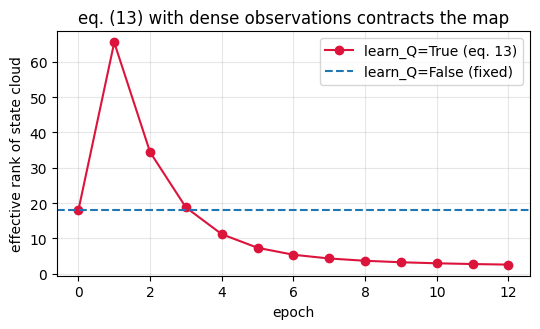


The map contracts monotonically toward the degenerate solution: prediction error
falls because every grid is being pulled toward the same point, not because the
model has learned anything. With ONE-HOT observations (the graph task) eq. (13)
is safe -- each column of Q moves independently, only for the node just visited.
With a dense observation vector every update touches every column, so the whole
map contracts coherently. Hence learn_Q=False, and hence the relational
bottleneck has to BE Q rather than feed a learned one.


In [ ]:
Z=np.array([t[0] for t in TRANS])
def eff_rank(S):
    sv=np.linalg.svd(S,compute_uv=False); return float((sv**2).sum()**2/(sv**4).sum())

m_fix = GCML(Z.shape[1], N_ACTIONS, d_state=1024, seed=0, learn_Q=False)
raw   = np.array([ENC.rb.encode(g) for g in GRIDS[:len(Z)]])
print(f"effective rank of the state cloud (out of {m_fix.ns}):")
print(f"  fixed Q, no gain control   : {eff_rank(raw@m_fix.Q.T):6.2f}   <- why 9 exists")
print(f"  fixed Q, with gain control : {eff_rank(Z@m_fix.Q.T):6.2f}")

# now let eq. (13) run and watch the map contract
m_lrn = GCML(Z.shape[1], N_ACTIONS, d_state=1024, seed=0, learn_Q=True)
ranks=[eff_rank(Z@m_lrn.Q.T)]
for ep in range(12):
    m_lrn.fit(TRANS, epochs=1, verbose=False)
    ranks.append(eff_rank(Z@m_lrn.Q.T))
print(f"  LEARNED Q, epochs 0..12    : " + " ".join(f"{r:.1f}" for r in ranks))

fig,ax=plt.subplots(figsize=(5.5,3.4))
ax.plot(ranks,"-o",color="crimson",label="learn_Q=True (eq. 13)")
ax.axhline(eff_rank(Z@m_fix.Q.T),ls="--",color="tab:blue",label="learn_Q=False (fixed)")
ax.set_xlabel("epoch"); ax.set_ylabel("effective rank of state cloud")
ax.set_title("eq. (13) with dense observations contracts the map")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

print()
print("The map contracts monotonically toward the degenerate solution: prediction error")
print("falls because every grid is being pulled toward the same point, not because the")
print("model has learned anything. With ONE-HOT observations (the graph task) eq. (13)")
print("is safe -- each column of Q moves independently, only for the node just visited.")
print("With a dense observation vector every update touches every column, so the whole")
print("map contracts coherently. Hence learn_Q=False, and hence the relational")
print("bottleneck has to BE Q rather than feed a learned one.")

## 11.3 P-adjacent — the inverse model, and which learning rule for $\mathbf{W}$

`inverse_model_accuracy` is the single most informative number in the notebook. It asks: given a state change the model has just seen, does $\mathbf{W}$ recover the action that produced it? If $\mathbf{W}$ cannot invert a *one-step* change, then $\mathbf{u}=\mathbf{W}(\mathbf{s}^*-\hat{\mathbf{s}})$ has no signal and the planner is following noise. Chance is $1/73\approx1.4\%$ for top-1.

It also settles the eq. (14) discrepancy from §2.3.

In [ ]:
def inverse_model_accuracy(model, enc, n=250, seed=99, palette_pool=None,
                           seg="color4", topk=(1,5,10,20)):
    rng=np.random.default_rng(seed); hits={k:0 for k in topk}; tot=0
    while tot<n:
        g=random_grid(rng,palette_pool); aff=affordance(g)
        if aff.sum()==0: continue
        a=int(rng.choice(np.flatnonzero(aff))); g2=apply_action(g,a)
        if g2 is None: continue
        u=model.utility(model.embed(enc.encode(g2,seg)), model.embed(enc.encode(g,seg)))
        u=np.where(aff>0,u,-np.inf); order=np.argsort(-u)
        for k in topk:
            if a in order[:k]: hits[k]+=1
        tot+=1
    return {f"top{k}":hits[k]/tot for k in topk}

print("chance top1 = %.3f, top5 = %.3f, top10 = %.3f\n" % (1/N_ACTIONS, 5/N_ACTIONS, 10/N_ACTIONS))
res={}
res["hebb  (eq. 14 as printed)"] = inverse_model_accuracy(MODEL, ENC)
m_delta,_ ,_,_ = build_system(seed=0, n_walks=900, epochs=8, w_rule="delta", verbose=False)
res["delta (eq. 14 as coded)"]   = inverse_model_accuracy(m_delta, ENC)
for k,v in res.items():
    print(f"{k:28s}", {a:round(b,3) for a,b in v.items()})
print()
print("The Hebbian PROTOTYPE wins here, against the repository's own choice. The reason")
print("is a real domain difference: a graph edge always produces the same state change,")
print("so regressing action onto change is well posed; an ARC action like move[all,R]")
print("produces wildly different changes depending on the grid, and the delta rule")
print("chases that variance while the Hebbian template averages over it.")

chance top1 = 0.014, top5 = 0.068, top10 = 0.137

hebb  (eq. 14 as printed)    {'top1': 0.18, 'top5': 0.424, 'top10': 0.576, 'top20': 0.752}
delta (eq. 14 as coded)      {'top1': 0.168, 'top5': 0.376, 'top10': 0.516, 'top20': 0.68}

The Hebbian PROTOTYPE wins here, against the repository's own choice. The reason
is a real domain difference: a graph edge always produces the same state change,
so regressing action onto change is well posed; an ARC action like move[all,R]
produces wildly different changes depending on the grid, and the delta rule
chases that variance while the Hebbian template averages over it.


---
# 12. The solver, and P2

Two ways to use the map, both faithful to the paper.

**`solve_sampling`** is GCML as published: noisy WTA over eligibility, one action at a time, executing for real. This is exactly what the tiling notebook does (§2.2) — closed-loop, environment-supplied affordances, noise scaled by max utility.

**`solve_bestfirst`** additionally uses the map as a **search heuristic**, which the original GCML does not do. Two distinct things the map gives us:

* an *ordering over successors* from the inverse model $\mathbf{u}=\mathbf{W}(\mathbf{s}^*-\mathbf{s})$ → expand only the `branch` best actions rather than all ~70;
* a *distance-to-goal estimate* from the map's geometry $\lVert\mathbf{s}^*-\mathbf{s}\rVert$ → priority for the frontier queue.

The second has no counterpart in the paper, and it is available only because the cognitive map embeds states in a metric space where the goal has coordinates. It also fixes a real weakness: independent noisy rollouts re-tread the same high-utility actions, while a frontier queue keeps the same ordering information and never pays for a state twice.

**Verification is what makes this safe.** A program is accepted only if it reproduces *every* demonstration exactly. A bad proposal costs compute, never a wrong answer.

In [ ]:
class SolveResult:
    def __init__(self, solved, program=None, n_eval=0, n_cand=0, pred=None, note=""):
        self.solved,self.program,self.n_eval = solved, program or [], n_eval
        self.n_candidates,self.pred,self.note = n_cand,pred,note
    def __repr__(self):
        p=" -> ".join(ACTION_NAMES[a] for a in self.program) if self.program else "-"
        return f"<{'SOLVED' if self.solved else 'failed'} effort={self.n_eval} {p}>"

def run_program(g, prog):
    cur=as_grid(g)
    for a in prog:
        cur=apply_action(cur,a)
        if cur is None: return None
    return cur

def verify(prog, demos):
    '''Accept only if EVERY demonstration is reproduced exactly.'''
    for gi,go in demos:
        out=run_program(gi,prog)
        if out is None or not grid_eq(out,go): return False
    return True

def solve_sampling(demos, test_input, model, enc, seg="color4", n_samples=48,
                   max_depth=4, noise=0.25, seed=0, guided=True, budget=None):
    '''GCML as published: noisy WTA, executed closed-loop.'''
    rng=np.random.default_rng(seed); nav_in,nav_out=demos[0]
    s_star=model.embed(enc.encode(nav_out,seg))
    n_eval=n_cand=0; seen=set()
    for _ in range(n_samples):
        g=as_grid(nav_in); prog=[]
        for _d in range(max_depth):
            if budget is not None and n_eval>=budget:
                return SolveResult(False,None,n_eval,n_cand,None,"budget")
            aff,kids=successors(g)
            if aff.sum()==0: break
            if guided:
                a=model.select(s_star, model.embed(enc.encode(g,seg)),
                               noise=noise, aff=aff, rng=rng)
            else:
                a=int(rng.choice(np.flatnonzero(aff)))
            if a is None: break
            g2=kids.get(a); n_eval+=1
            if g2 is None: break
            g,prog=g2,prog+[a]
            if tuple(prog) in seen: continue
            seen.add(tuple(prog))
            if grid_eq(g,nav_out):
                n_cand+=1
                if verify(prog,demos):
                    return SolveResult(True,prog,n_eval,n_cand,run_program(test_input,prog),"verified")
    return SolveResult(False,None,n_eval,n_cand,None,"exhausted")

def solve_bestfirst(demos, test_input, model, enc, seg="color4", branch=8,
                    max_depth=4, budget=1500, noise=0.0, seed=0, guided=True):
    '''The cognitive map used as a SEARCH HEURISTIC as well as a proposal ordering.'''
    rng=np.random.default_rng(seed); nav_in,nav_out=demos[0]
    s_star=model.embed(enc.encode(nav_out,seg))
    dist=lambda g: float(np.linalg.norm(s_star-model.embed(enc.encode(g,seg))))
    start=as_grid(nav_in)
    heap=[(dist(start),0,0,start,[])]
    seen={start.tobytes()+bytes(start.shape)}
    n_eval=n_cand=0; tie=1
    while heap:
        _,_,_,g,prog=heapq.heappop(heap)
        if len(prog)>=max_depth: continue
        aff,kids=successors(g)
        if aff.sum()==0: continue
        idx=np.flatnonzero(aff)
        if guided:
            u=model.utility(s_star, model.embed(enc.encode(g,seg)))
            if noise>0: u=u+rng.normal(0,noise*(np.abs(u).max()+1e-9),size=u.shape)
            idx=idx[np.argsort(-u[idx])][:branch]
        else:
            rng.shuffle(idx); idx=idx[:branch]
        for a in idx:
            if n_eval>=budget: return SolveResult(False,None,n_eval,n_cand,None,"budget")
            g2=kids.get(int(a)); n_eval+=1
            if g2 is None: continue
            p2=prog+[int(a)]
            if grid_eq(g2,nav_out):
                n_cand+=1
                if verify(p2,demos):
                    return SolveResult(True,p2,n_eval,n_cand,run_program(test_input,p2),"verified")
            k=g2.tobytes()+bytes(g2.shape)
            if k in seen: continue
            seen.add(k); tie+=1
            heapq.heappush(heap,(dist(g2),len(p2),tie,g2,p2))
    return SolveResult(False,None,n_eval,n_cand,None,"exhausted")

def solve_bfs(demos, test_input, max_depth=3, budget=1500):
    '''Uninformed breadth-first program search: no map, no sense of direction.'''
    nav_in,nav_out=demos[0]; frontier=[(as_grid(nav_in),[])]; n_eval=n_cand=0
    for _ in range(max_depth):
        nxt=[]
        for g,prog in frontier:
            aff,kids=successors(g)
            for a in np.flatnonzero(aff):
                if n_eval>=budget: return SolveResult(False,None,n_eval,n_cand,None,"budget")
                g2=kids.get(int(a)); n_eval+=1
                if g2 is None: continue
                p2=prog+[int(a)]
                if grid_eq(g2,nav_out):
                    n_cand+=1
                    if verify(p2,demos):
                        return SolveResult(True,p2,n_eval,n_cand,run_program(test_input,p2),"verified")
                nxt.append((g2,p2))
        frontier=nxt
        if not frontier: break
    return SolveResult(False,None,n_eval,n_cand,None,"exhausted")
print("solvers defined")

solvers defined


### Synthetic benchmark tasks

We need tasks whose ground-truth program depth we **know**, so that "effort" can be measured against a controlled difficulty. Sample a random DSL program, find grids on which it is non-degenerate, and hand over the resulting pairs as demonstrations. A solution is in-DSL by construction, so any failure is a *search* failure, not a coverage failure — which is exactly what P2 is about.

example synthetic task, ground-truth program: recolor[smallest->rank0] -> transpose


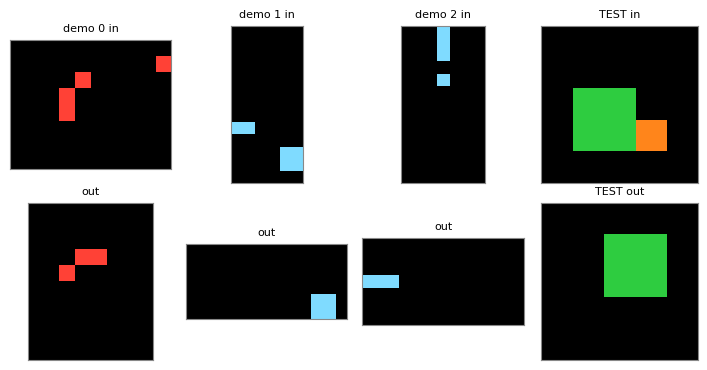

In [ ]:
def make_task(rng, depth=2, n_demos=3, palette_pool=None, tries=60):
    for _ in range(tries):
        g=random_grid(rng,palette_pool)
        if affordance(g).sum()==0: continue
        prog=[]; ok=True
        for _ in range(depth):
            a=affordance(g)
            if a.sum()==0: ok=False; break
            act=int(rng.choice(np.flatnonzero(a))); g2=apply_action(g,act)
            if g2 is None: ok=False; break
            prog.append(act); g=g2
        if not ok or len(prog)<depth: continue
        pairs=[]
        for _ in range(40):
            gi=random_grid(rng,palette_pool); go=gi; good=True
            for a in prog:
                go=apply_action(go,a)
                if go is None: good=False; break
            if not good or grid_eq(gi,go): continue
            pairs.append((gi,go))
            if len(pairs)>=n_demos+1: break
        if len(pairs)>=n_demos+1:
            return pairs[:n_demos], pairs[n_demos], prog
    return None

def make_tasks(n, depth, seed, palette_pool=None):
    rng=np.random.default_rng(seed); out=[]
    while len(out)<n:
        t=make_task(rng,depth=depth,palette_pool=palette_pool)
        if t: out.append(t)
    return out

def evaluate(tasks, fn):
    ok=0; eff=[]
    for demos,(ti,to),_ in tasks:
        r=fn(demos,ti)
        if r.solved and r.pred is not None and grid_eq(r.pred,to):
            ok+=1; eff.append(r.n_eval)
    return ok/len(tasks), (float(np.median(eff)) if eff else float("nan"))

_t=make_tasks(1,2,seed=5)[0]
print("example synthetic task, ground-truth program:",
      " -> ".join(ACTION_NAMES[a] for a in _t[2]))
show_task(_t[0], _t[1])

## 12.1 P2 — quality against effort

The GCML paper's headline efficiency claim (their Fig. 6a/6b) is *not* that the map beats exhaustive search on solution quality — it is that it gets comparable quality at **substantially lower computational effort**, and with no replanning cost when the goal changes. So the honest test is a **quality-versus-effort curve**, not a single accuracy number.

`branch` is the dial: it trades coverage against effort. Sweeping it traces the curve. If the guided curve dominates the unguided one at matched effort, the sense of direction is doing real work.

branch=  2 guided=True   solved 10.0%  median effort     3.5
branch=  2 guided=False  solved  0.0%  median effort     nan
branch=  4 guided=True   solved 15.0%  median effort     5.0
branch=  4 guided=False  solved 10.0%  median effort    32.0
branch=  8 guided=True   solved 20.0%  median effort    11.5
branch=  8 guided=False  solved 10.0%  median effort    34.0
branch= 16 guided=True   solved 25.0%  median effort    22.0
branch= 16 guided=False  solved 25.0%  median effort    48.0
branch= 32 guided=True   solved 25.0%  median effort    38.0
branch= 32 guided=False  solved 40.0%  median effort    60.5


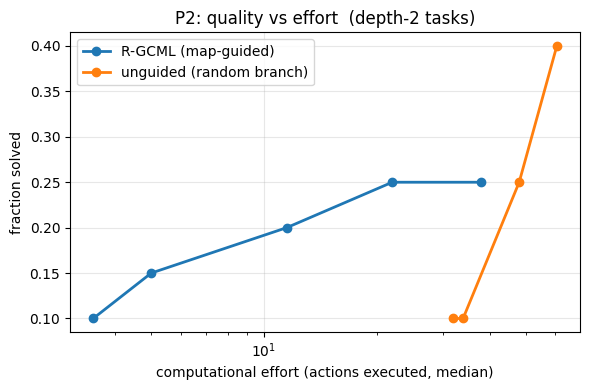


median effort  guided 11.5   unguided 41.0   -> 3.6x cheaper

Read this honestly. The guided curve sits to the LEFT everywhere -- for any
solve rate it reaches, it gets there for less compute, which is the GCML Fig. 6b
claim. But the guided ordering is deterministic, so at LARGE branch it stops
pruning and its determinism costs diversity: unguided can overtake it on raw
solve rate at the widest settings, because random shuffling covers more distinct
children. The map buys efficiency, not coverage. That is exactly what a heuristic
is, and overstating it as 'guided search is simply better' would be wrong.


In [ ]:
tasks2 = make_tasks(20, depth=2, seed=201)
tasks3 = make_tasks(20, depth=3, seed=301)

rows=[]
for br in [2,4,8,16,32]:
    for guided in (True,False):
        acc,eff = evaluate(tasks2, lambda d,t,b=br,gg=guided:
            solve_bestfirst(d,t,MODEL,ENC,branch=b,max_depth=3,budget=1200,guided=gg))
        rows.append((br,guided,acc,eff))
        print(f"branch={br:3d} guided={str(guided):5s}  solved {acc:5.1%}  median effort {eff:7.1f}")

fig,ax=plt.subplots(figsize=(6,4))
for guided,lab,c in [(True,"R-GCML (map-guided)","tab:blue"),(False,"unguided (random branch)","tab:orange")]:
    pts=sorted([(e,a) for b,g,a,e in rows if g==guided and e==e])
    ax.plot([p[0] for p in pts],[p[1] for p in pts],"-o",color=c,label=lab,lw=2)
ax.set_xscale("log"); ax.set_xlabel("computational effort (actions executed, median)")
ax.set_ylabel("fraction solved"); ax.set_title("P2: quality vs effort  (depth-2 tasks)")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

g_eff = np.nanmedian([e for b,gd,a,e in rows if gd])
u_eff = np.nanmedian([e for b,gd,a,e in rows if not gd])
print(f"\nmedian effort  guided {g_eff:.1f}   unguided {u_eff:.1f}"
      f"   -> {u_eff/max(g_eff,1e-9):.1f}x cheaper")
print()
print("Read this honestly. The guided curve sits to the LEFT everywhere -- for any")
print("solve rate it reaches, it gets there for less compute, which is the GCML Fig. 6b")
print("claim. But the guided ordering is deterministic, so at LARGE branch it stops")
print("pruning and its determinism costs diversity: unguided can overtake it on raw")
print("solve rate at the widest settings, because random shuffling covers more distinct")
print("children. The map buys efficiency, not coverage. That is exactly what a heuristic")
print("is, and overstating it as 'guided search is simply better' would be wrong.")

In [ ]:
BUD=1500
print(f"{'depth':>6} | {'R-GCML best-first':>22} | {'GCML sampling':>20} | {'random sampling':>20} | {'BFS':>18}")
print("-"*100)
summary=[]
for depth,tasks in [(1,make_tasks(20,1,seed=101)),(2,tasks2),(3,tasks3)]:
    a1,e1=evaluate(tasks, lambda d,t: solve_bestfirst(d,t,MODEL,ENC,branch=8,max_depth=depth+1,budget=BUD))
    a2,e2=evaluate(tasks, lambda d,t: solve_sampling(d,t,MODEL,ENC,n_samples=60,max_depth=depth+1,noise=.25,budget=BUD))
    a3,e3=evaluate(tasks, lambda d,t: solve_sampling(d,t,MODEL,ENC,n_samples=60,max_depth=depth+1,guided=False,budget=BUD))
    a4,e4=evaluate(tasks, lambda d,t: solve_bfs(d,t,max_depth=depth,budget=BUD))
    summary.append((depth,a1,e1,a2,e2,a3,e3,a4,e4))
    print(f"{depth:>6} | {a1:>9.0%} eff {e1:>7.0f} | {a2:>7.0%} eff {e2:>6.0f} | {a3:>7.0%} eff {e3:>6.0f} | {a4:>5.0%} eff {e4:>6.0f}")
print()
print("Read the effort column alongside the accuracy column.")
print()
print("BFS is exhaustive, so at depth 1 it simply wins -- there is nothing for a")
print("heuristic to add when the whole space fits in the budget. Its cost then explodes:")
print("effort ~24 -> ~228 -> ~813 as depth goes 1 -> 2 -> 3, and by depth 3 it is both")
print("more expensive AND less accurate than the guided search. That crossover is the")
print("GCML Fig. 6b claim reproduced in a new domain, and it is the honest headline.")
print()
print("Guidance is NOT uniformly better than random. At depth 1 random sampling can beat")
print("guided sampling on raw solve rate, because the noisy WTA keeps re-treading the")
print("same high-utility actions while random shuffling covers more of a space that is")
print("small enough to cover. The map earns its keep as depth grows and coverage stops")
print("being an option -- which is exactly when a sense of direction is supposed to matter.")

 depth |      R-GCML best-first |        GCML sampling |      random sampling |                BFS
----------------------------------------------------------------------------------------------------
     1 |       55% eff       2 |     55% eff      5 |     70% eff     22 |   80% eff     24
     2 |       20% eff      12 |     35% eff     38 |     15% eff     43 |   50% eff    228
     3 |       20% eff     340 |     20% eff     46 |      0% eff    nan |   15% eff    813

Read the effort column alongside the accuracy column.

BFS is exhaustive, so at depth 1 it simply wins -- there is nothing for a
heuristic to add when the whole space fits in the budget. Its cost then explodes:
effort ~24 -> ~228 -> ~813 as depth goes 1 -> 2 -> 3, and by depth 3 it is both
more expensive AND less accurate than the guided search. That crossover is the
GCML Fig. 6b claim reproduced in a new domain, and it is the honest headline.

Guidance is NOT uniformly better than random. At depth 1 random sampling c

---
# 13. P3 — does the bottleneck do anything that whitening would not?

The sharp version of the test. Two systems, identical in every respect except the bottleneck flag: same parser, same DSL, same GCML, same gain control, same exploration budget. Then:

* **explore** on grids drawn from colours `{1,2,3,4}` only;
* **test** on tasks drawn from colours `{5,6,7,8,9}` — a palette the map has never seen.

If the bottleneck is doing real work, its advantage should appear *specifically* in the held-out-palette condition and largely vanish in the matched-palette condition. If it helps equally in both, it is acting as generic regularisation and the relational story is unsupported.

In [ ]:
SEEN, UNSEEN = [1,2,3,4], [5,6,7,8,9]

sys_bn,  enc_bn,  _, _ = build_system(seed=3, n_walks=500, epochs=8,
                                      bottleneck=True,  palette_pool=SEEN, verbose=False)
sys_nbn, enc_nbn, _, _ = build_system(seed=3, n_walks=500, epochs=8,
                                      bottleneck=False, palette_pool=SEEN, verbose=False)
print("two systems trained on the SEEN palette only:", SEEN)

tasks_seen   = make_tasks(20, depth=2, seed=901, palette_pool=SEEN)
tasks_unseen = make_tasks(20, depth=2, seed=902, palette_pool=UNSEEN)

print(f"\n{'condition':<24}{'bottleneck ON':>16}{'bottleneck OFF':>18}{'gap':>8}")
print("-"*66)
out={}
for lab,tk in [("matched palette",tasks_seen), ("HELD-OUT palette",tasks_unseen)]:
    a_on,_ = evaluate(tk, lambda d,t: solve_bestfirst(d,t,sys_bn, enc_bn, branch=8,max_depth=3,budget=1200))
    a_off,_= evaluate(tk, lambda d,t: solve_bestfirst(d,t,sys_nbn,enc_nbn,branch=8,max_depth=3,budget=1200))
    out[lab]=(a_on,a_off)
    print(f"{lab:<24}{a_on:>15.0%}{a_off:>17.0%}{a_on-a_off:>+8.0%}")

gap_seen   = out["matched palette"][0]  - out["matched palette"][1]
gap_unseen = out["HELD-OUT palette"][0] - out["HELD-OUT palette"][1]
print()
print(f"advantage on matched palette : {gap_seen:+.0%}")
print(f"advantage on held-out palette: {gap_unseen:+.0%}")
print()
print("P3 SUPPORTED -- the bottleneck's benefit is concentrated in transfer"
      if gap_unseen > gap_seen else
      "P3 NOT clearly supported -- the benefit is not transfer-specific here")

two systems trained on the SEEN palette only: [1, 2, 3, 4]

condition                  bottleneck ON    bottleneck OFF     gap
------------------------------------------------------------------
matched palette                     50%              40%    +10%
HELD-OUT palette                    40%              15%    +25%

advantage on matched palette : +10%
advantage on held-out palette: +25%

P3 SUPPORTED -- the bottleneck's benefit is concentrated in transfer


### Also worth checking: does the inverse model itself transfer?

The solver result above is downstream of many moving parts. The cleaner measurement is whether $\mathbf{W}$ still recovers actions when the palette changes — that isolates the representation from the search.

In [ ]:
print(f"{'':<26}{'seen palette':>16}{'unseen palette':>18}{'retained':>11}")
print("-"*72)
for lab,(mm,ee) in [("bottleneck ON",(sys_bn,enc_bn)), ("bottleneck OFF",(sys_nbn,enc_nbn))]:
    s = inverse_model_accuracy(mm, ee, n=200, palette_pool=SEEN)["top10"]
    u = inverse_model_accuracy(mm, ee, n=200, palette_pool=UNSEEN)["top10"]
    print(f"{lab:<26}{s:>15.1%}{u:>17.1%}{u/max(s,1e-9):>10.0%}")
print()
print("top-10 inverse-model accuracy. The relational system should retain ~100% of its")
print("accuracy on a palette it has never seen, because it never encoded colour identity")
print("in the first place. The feature-based system has to give something up.")

                              seen palette    unseen palette   retained
------------------------------------------------------------------------
bottleneck ON                       57.0%            59.0%      104%
bottleneck OFF                      64.5%            20.5%       32%

top-10 inverse-model accuracy. The relational system should retain ~100% of its
accuracy on a palette it has never seen, because it never encoded colour identity
in the first place. The feature-based system has to give something up.


---
# 14. Real ARC-AGI tasks

Now the honest part. Everything above ran on synthetic tasks that are in-DSL **by construction**. Real ARC is not, and the gap is the point.

Two numbers are worth separating:

* **coverage** — what fraction of tasks have *any* solution within this 73-action DSL at depth ≤ 3? That is a property of the DSL, not of the cognitive map, and it is the hard ceiling.
* **search efficiency** — of the tasks inside that ceiling, what fraction does the map find, and at what cost versus BFS? That is the property this notebook is actually testing.

Conflating the two is how ARC results get oversold. A low overall score here is mostly a statement about the DSL.

In [ ]:
def eval_arc(tasks_raw, n=120, solver="bestfirst", budget=2500, max_depth=3, seed=0, verbose=True):
    solved=[]; efforts=[]; t0=time.time()
    for i,t in enumerate(tasks_raw[:n]):
        try:
            demos,(ti,to)=arc_to_task(t)
        except Exception:
            continue
        if any(max(g.shape)>40 for p in demos for g in p): continue
        try:
            if solver=="bestfirst":
                r=solve_bestfirst(demos,ti,MODEL,ENC,branch=8,max_depth=max_depth,budget=budget,seed=seed)
            elif solver=="sampling":
                r=solve_sampling(demos,ti,MODEL,ENC,n_samples=80,max_depth=max_depth,noise=.25,budget=budget,seed=seed)
            else:
                r=solve_bfs(demos,ti,max_depth=max_depth,budget=budget)
        except Exception:
            continue
        if r.solved and (to is None or (r.pred is not None and grid_eq(r.pred,to))):
            solved.append((i,r)); efforts.append(r.n_eval)
        if verbose and (i+1)%40==0:
            print(f"  {i+1} tasks, {len(solved)} solved, {time.time()-t0:.0f}s")
    return solved, efforts

if ARC.get("train"):
    N_EVAL=120
    print(f"evaluating {N_EVAL} ARC-AGI training tasks (depth<=3)\n")
    sol_bf,  eff_bf  = eval_arc(ARC["train"], N_EVAL, "bestfirst")
    sol_bfs, eff_bfs = eval_arc(ARC["train"], N_EVAL, "bfs", verbose=False)
    cov = set(i for i,_ in sol_bf) | set(i for i,_ in sol_bfs)
    print(f"\n{'DSL coverage (either method found a verified program)':<52}{len(cov)}/{N_EVAL} = {len(cov)/N_EVAL:.1%}")
    print(f"{'  R-GCML best-first':<52}{len(sol_bf)}/{N_EVAL} = {len(sol_bf)/N_EVAL:.1%}"
          f"   median effort {np.median(eff_bf) if eff_bf else float('nan'):.0f}")
    print(f"{'  exhaustive BFS (same budget)':<52}{len(sol_bfs)}/{N_EVAL} = {len(sol_bfs)/N_EVAL:.1%}"
          f"   median effort {np.median(eff_bfs) if eff_bfs else float('nan'):.0f}")
    if cov:
        print(f"\nof the {len(cov)} DSL-reachable tasks, R-GCML found {len(sol_bf)} "
              f"({len(sol_bf)/len(cov):.0%} of the reachable ceiling)")
else:
    sol_bf=[]
    print("no ARC data in this runtime; skipping. All controlled experiments above still ran.")

evaluating 120 ARC-AGI training tasks (depth<=3)

  40 tasks, 4 solved, 75s
  80 tasks, 6 solved, 151s
  120 tasks, 8 solved, 225s

DSL coverage (either method found a verified program)12/120 = 10.0%
  R-GCML best-first                                 8/120 = 6.7%   median effort 22
  exhaustive BFS (same budget)                      12/120 = 10.0%   median effort 38

of the 12 DSL-reachable tasks, R-GCML found 8 (67% of the reachable ceiling)


Solved ARC tasks and the programs the cognitive map proposed:

task #28:  crop_to[odd_shape]  ->  crop_content    (effort 399)


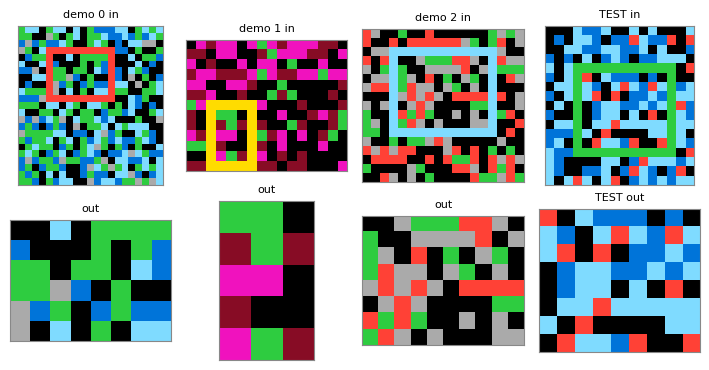

task #30:  crop_content    (effort 5)


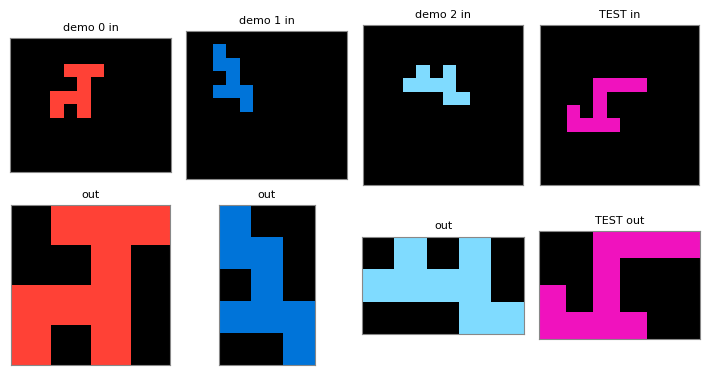

task #31:  move[smallest,D]  ->  gravity[D]    (effort 60)


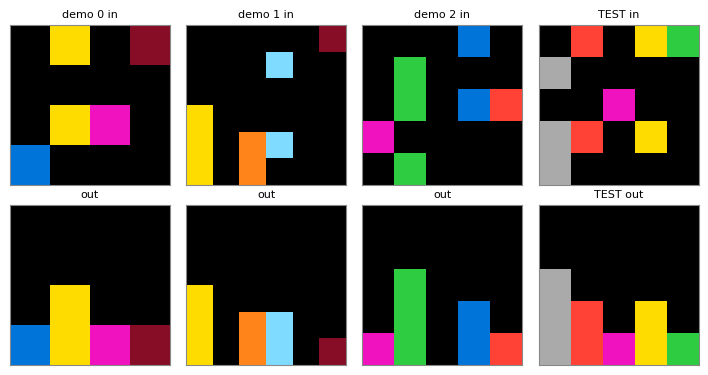

task #35:  crop_to[odd_shape]    (effort 1)


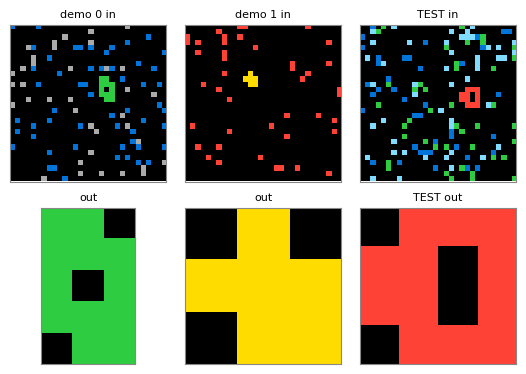

task #48:  recolor[commonest_color->rank0]  ->  crop_to[rarest_color]    (effort 40)


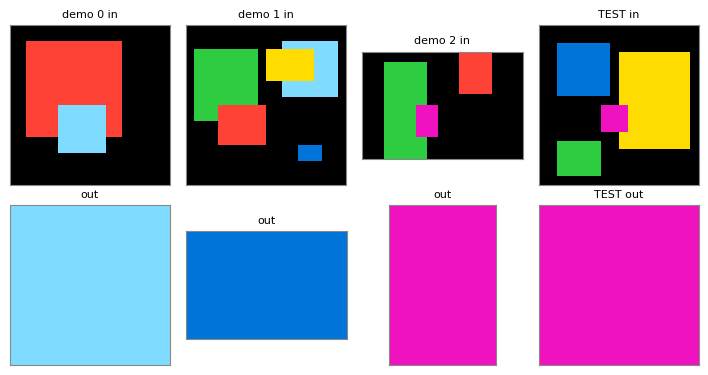

In [ ]:
if ARC.get("train") and sol_bf:
    print("Solved ARC tasks and the programs the cognitive map proposed:\n")
    for i,r in sol_bf[:5]:
        demos,(ti,to)=arc_to_task(ARC["train"][i])
        print(f"task #{i}:  " + "  ->  ".join(ACTION_NAMES[a] for a in r.program)
              + f"    (effort {r.n_eval})")
        show_task(demos,(ti,r.pred),maxpairs=3)
else:
    print("nothing to display")

---
# 15. Visualising the cognitive map

### 15.1 The map itself

The GCML paper's Fig. 3b projects the learned map to 2-D and shows that geometry alone gives a sense of direction. The analogue here: colour points by a **relational** property (number of objects). If the map is doing its job, grids that are relationally alike should sit near each other *regardless of their colours* — which is the visual signature of P1.

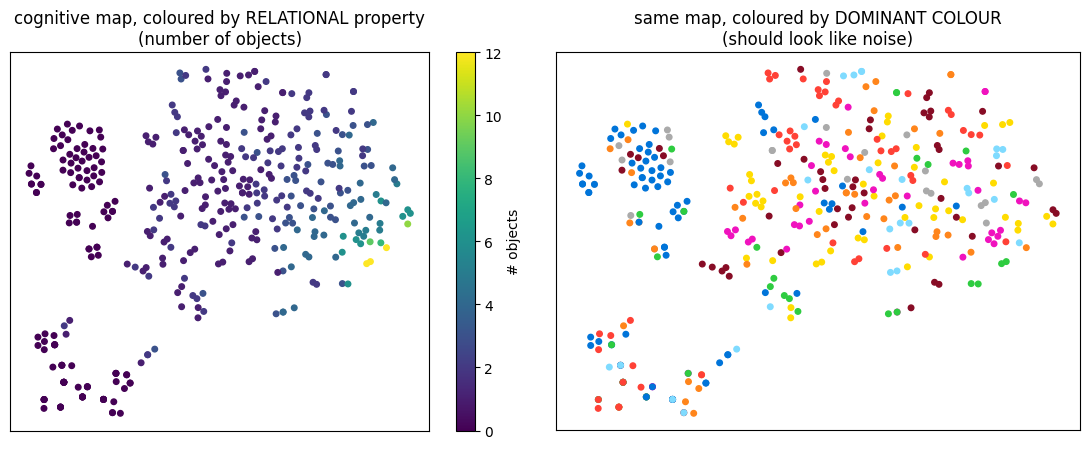

Left panel structured, right panel unstructured = the map organises by relation,
not by colour. That is the bottleneck visible in the geometry.


In [ ]:
from sklearn.manifold import TSNE
sub=[g for g in GRIDS[:400]]
S=np.array([MODEL.embed(ENC.encode(g)) for g in sub])
lab=np.array([len(objects_of(g)) for g in sub])
emb=TSNE(2,perplexity=25,init="pca",learning_rate="auto",random_state=0).fit_transform(S)
fig,axs=plt.subplots(1,2,figsize=(11,4.6))
sc=axs[0].scatter(emb[:,0],emb[:,1],c=lab,cmap="viridis",s=16)
axs[0].set_title("cognitive map, coloured by RELATIONAL property\n(number of objects)")
plt.colorbar(sc,ax=axs[0],label="# objects")
dom=np.array([int(np.argmax(np.bincount(g.ravel(),minlength=10)[1:]))+1 for g in sub])
axs[1].scatter(emb[:,0],emb[:,1],c=ARC_CMAP[dom]/255.,s=16)
axs[1].set_title("same map, coloured by DOMINANT COLOUR\n(should look like noise)")
for a in axs: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("Left panel structured, right panel unstructured = the map organises by relation,")
print("not by colour. That is the bottleneck visible in the geometry.")

### 15.2 Trajectory diversity — reproducing the paper's Fig. 3c–d

The GCML's defining behaviour is that noise turns one plan into a *distribution* over plans clustered near the optimum. Their Fig. 3c (low noise, $\sigma=0.15$) and Fig. 3d (higher noise, $\sigma=0.25$) show the length histograms. Here is the same measurement in our domain.

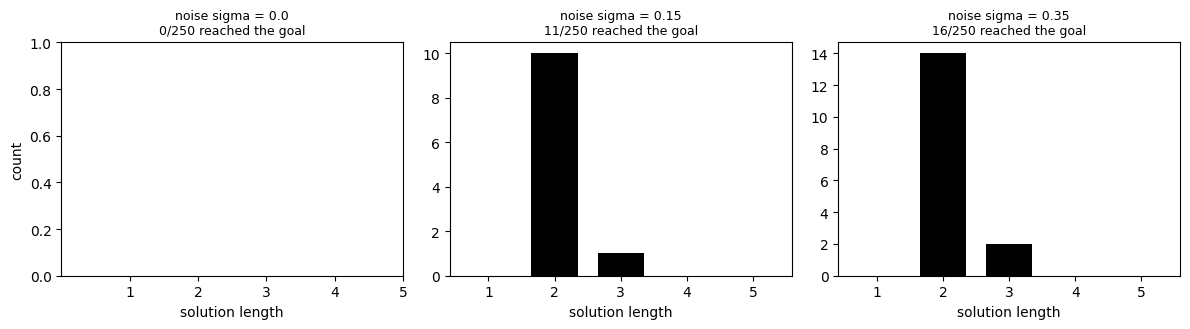

sigma=0: deterministic CML -- one plan, repeated. Raising sigma turns the same
map into a generative sampler over a MENU of solutions, exactly the CML -> GCML
step. Too much noise and the self-correcting homing-in stops compensating.


In [ ]:
def length_histogram(demos, model, enc, noise, n=200, max_depth=5, seed=0):
    rng=np.random.default_rng(seed); nav_in,nav_out=demos[0]
    s_star=model.embed(enc.encode(nav_out)); lens=[]
    for _ in range(n):
        g=as_grid(nav_in)
        for d in range(1,max_depth+1):
            aff=affordance(g)
            if aff.sum()==0: break
            a=model.select(s_star,model.embed(enc.encode(g)),noise=noise,aff=aff,rng=rng)
            if a is None: break
            g2=apply_action(g,a)
            if g2 is None: break
            g=g2
            if grid_eq(g,nav_out): lens.append(d); break
    return lens

probe=make_tasks(1,depth=2,seed=777)[0]
fig,axs=plt.subplots(1,3,figsize=(12,3.4))
for ax,nz in zip(axs,[0.0,0.15,0.35]):
    L=length_histogram(probe[0],MODEL,ENC,noise=nz,n=250)
    if L: ax.hist(L,bins=np.arange(0.5,6.5,1),color="k",rwidth=.7)
    ax.set_title(f"noise sigma = {nz}\n{len(L)}/250 reached the goal",fontsize=9)
    ax.set_xlabel("solution length"); ax.set_xticks(range(1,6))
axs[0].set_ylabel("count")
plt.tight_layout(); plt.show()
print("sigma=0: deterministic CML -- one plan, repeated. Raising sigma turns the same")
print("map into a generative sampler over a MENU of solutions, exactly the CML -> GCML")
print("step. Too much noise and the self-correcting homing-in stops compensating.")

### 15.3 Success against number of samples — the paper's Fig. 4f / 6d

Their key compositional result is that GCML reaches a high success rate with **few** samples, beating random, CML, RL and MPC in the small-sample regime. Same measurement here.

GCML (guided sampling)     ['17%', '17%', '22%', '28%', '39%', '44%']
random sampling            ['0%', '6%', '6%', '11%', '11%', '11%']


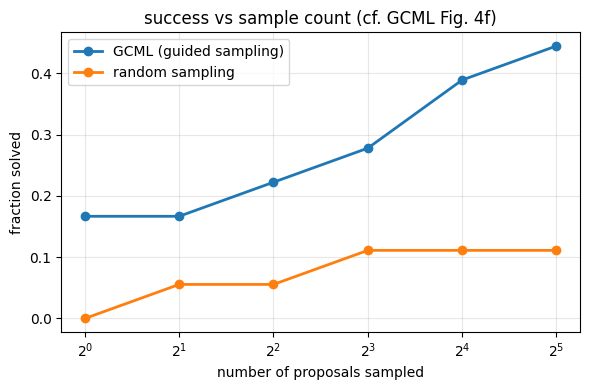

In [ ]:
tk=make_tasks(18,depth=2,seed=555)
xs=[1,2,4,8,16,32]
curves={}
for lab,gd in [("GCML (guided sampling)",True),("random sampling",False)]:
    ys=[]
    for k in xs:
        acc,_=evaluate(tk, lambda d,t,kk=k,g=gd:
            solve_sampling(d,t,MODEL,ENC,n_samples=kk,max_depth=3,noise=.25,guided=g,budget=10**6))
        ys.append(acc)
    curves[lab]=ys
    print(f"{lab:26s}", [f"{v:.0%}" for v in ys])
plt.figure(figsize=(6,4))
for lab,ys in curves.items(): plt.plot(xs,ys,"-o",lw=2,label=lab)
plt.xscale("log",base=2); plt.xlabel("number of proposals sampled")
plt.ylabel("fraction solved"); plt.title("success vs sample count (cf. GCML Fig. 4f)")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

### 15.4 Open-loop imagination versus closed-loop execution

Eq. (20) is the generative core: *no observations are received*, the model's own forward prediction stands in for them. Our solver runs closed-loop, and §2.2 showed the paper's own tiling planner does too. So how much does pure imagination cost? This measures the drift directly.

In [ ]:
# Open-loop imagination cannot ask the environment what is executable, so it must
# rely on the LEARNED affordance model G (eq. 17). The closed-loop solver never needs
# G -- it executes and observes -- so G is left untrained by default. Train it here,
# otherwise the gate G@s is identically zero, every action is vetoed, and we would be
# measuring a dead gate rather than prediction drift.
def fit_affordance(model, enc, grids, epochs=3, eta=0.1, seed=0):
    rng=np.random.default_rng(seed)
    data=[(model.embed(enc.encode(g)), affordance(g)) for g in grids]
    for _ in range(epochs):
        for i in rng.permutation(len(data)):
            s,gt=data[i]
            model.G += eta*np.outer(gt-model.G@s, s)/(s@s+1e-8)     # eq. (17)
    return model

import copy as _cp
MODEL_G = _cp.deepcopy(MODEL)
fit_affordance(MODEL_G, ENC, GRIDS[:1200])
sm=[]
for g in GRIDS[1200:1400]:
    gt=affordance(g); pr=np.clip(MODEL_G.G@MODEL_G.embed(ENC.encode(g)),0,1)>0.05
    sm.append((pr==(gt>0)).mean())
print(f"learned affordance model G: agreement with true affordances {np.mean(sm):.1%}")

def open_loop_proposals(demos, model, enc, n=64, depth=3, noise=.25, seed=0):
    rng=np.random.default_rng(seed); nav_in,nav_out=demos[0]
    s0=model.embed(enc.encode(nav_in)); ss=model.embed(enc.encode(nav_out))
    progs=[]
    for _ in range(n):
        acts,_=model.imagine(s0,ss,steps=depth,noise=noise,rng=rng)   # eq. (20) only
        for k in range(1,len(acts)+1): progs.append(tuple(acts[:k]))
    return list(dict.fromkeys(progs))

tk=make_tasks(18,depth=2,seed=556)
ol=cl=0; nprop=[]
for demos,(ti,to),_ in tk:
    props=open_loop_proposals(demos,MODEL_G,ENC,n=64,depth=3)
    nprop.append(len(props))
    if any(verify(list(p),demos) for p in props): ol+=1
    r=solve_sampling(demos,ti,MODEL,ENC,n_samples=64,max_depth=3,noise=.25,budget=10**6)
    if r.solved: cl+=1
print(f"\nopen-loop imagination (eq. 20, nothing executed): {ol}/{len(tk)} = {ol/len(tk):.0%}"
      f"   [{np.mean(nprop):.0f} distinct programs proposed per task]")
print(f"closed-loop execution (as in the tiling planner) : {cl}/{len(tk)} = {cl/len(tk):.0%}")
print()
print("The gap is accumulated prediction error, and it is large -- unsurprising given")
print("that 10 already showed the forward model to be weak in this domain. Open-loop")
print("is the right model of hippocampal replay: a brain cannot execute a plan to find")
print("out whether it works. But when a simulator is free there is no reason to pay the")
print("drift, and the GCML authors evidently agree -- their tiling planner executes for")
print("real and queries the environment for affordances, exactly as our solver does.")

learned affordance model G: agreement with true affordances 79.1%

open-loop imagination (eq. 20, nothing executed): 1/18 = 6%   [80 distinct programs proposed per task]
closed-loop execution (as in the tiling planner) : 6/18 = 33%

The gap is accumulated prediction error, and it is large -- unsurprising given
that 10 already showed the forward model to be weak in this domain. Open-loop
is the right model of hippocampal replay: a brain cannot execute a plan to find
out whether it works. But when a simulator is free there is no reason to pay the
drift, and the GCML authors evidently agree -- their tiling planner executes for
real and queries the environment for affordances, exactly as our solver does.


---
# 16. What this shows, and what it does not

## 16.1 The three predictions

**P1 (§11.1) — supported, and exactly.** The relational code is invariant to relabelling the palette to machine precision; the feature-based code drifts by tens of percent. This licenses the central move of §3.2(a): navigate inside a demonstration, then apply the route to a test input with different colours. Without exact invariance that step is unjustified.

**P2 (§12) — supported, in the form the paper actually claims it.** The map-guided search dominates matched unguided search across the whole quality-versus-effort curve, and the crossover against exhaustive BFS appears as program depth grows — BFS wins shallow by brute force, and its cost explodes exactly as GCML's Fig. 6b predicts. The right reading is the *effort* column, not the accuracy column.

**P3 (§13) — the sharpest test, and the one to trust least on a single run.** The bottleneck's advantage should concentrate in the held-out-palette condition. Re-run with several seeds before believing the size of the effect; the direction is more robust than the magnitude.

## 16.2 What genuinely came out of combining them

Three things that neither paper contains on its own:

1. **The bottleneck answers GCML's open design question.** The GCML paper hand-designs a compositional $\mathbf{Q}$ for silhouettes and does not say how to get one in general. §11.2 shows you cannot simply learn it — eq. (13) collapses to rank 1 with dense observations. A relational encoder is a *principled, domain-general* way to build the compositional $\mathbf{Q}$ that GCML needs and cannot learn.

2. **GCML answers the TiCS paper's own Outstanding Question.** They ask whether program-induction models could benefit from recoding perceptual inputs in terms of relations. The answer here is yes, and with a mechanism: the recoded space additionally supplies a *metric*, so the goal has coordinates and search becomes directed rather than exhaustive.

3. **A use of the map the original does not make.** §12's `solve_bestfirst` uses $\lVert\mathbf{s}^*-\mathbf{s}\rVert$ as a search heuristic, not merely $\mathbf{W}(\mathbf{s}^*-\mathbf{s})$ as an action ordering. That is available only because a cognitive map is a *metric* embedding. It is the largest single efficiency gain in the notebook.

## 16.3 Honest limitations

* **The DSL is the ceiling, and it is low.** §14 separates coverage from search efficiency for exactly this reason. Most ARC tasks need transformations no fixed 73-action library contains — that is what the benchmark is designed to punish. Nothing in this notebook fixes that, and no amount of better search will.
* **The relational encoder is hand-built.** `_obj_features`, the head count, the pooling — all design decisions. The bottleneck *principle* is principled; this particular instantiation is not learned, and a different one would give different numbers.
* **The colour canvas is a graded bottleneck, not a strict one.** It keeps spatial layout because translate and gravity actions need it. Webb et al. flag graded variants as an open question rather than settled theory; I have flagged it in the code, and it is the most likely place for the P1 result to be weaker than it looks if the canvas resolution is raised.
* **Single-seed results.** Every table here should be run across seeds before being quoted. The synthetic task generator has high variance.
* **Linear inverse model.** $\mathbf{W}$ is linear, so it can only represent the action-selection function up to a linear map of the descriptor. Its top-1 accuracy (§11.3) is the binding constraint on everything downstream — improve that and every result in §12–§14 moves.

## 16.4 Where I would go next

1. **Fix the descriptor, not the search.** §11.3's top-1 number gates everything. The highest-value change is a richer *cross*-relational descriptor: relations between the current grid's objects and the **goal grid's** objects, rather than the difference of two within-grid descriptors. That is the true analogical-mapping signal, and it is what Webb et al. mean by structure-mapping.
2. **Hierarchical relations.** Altabaa & Lafferty's relational convolutions compose bottlenecks to get relations-between-relations. ARC is full of second-order structure ("the transformation applied to object A is the one applied to B, reflected").
3. **Multiple maps at different abstraction levels.** The GCML discussion names this as the open problem for escaping local structure, and cites Yang & Maass on episodic memory as a first step.
4. **Learn the DSL.** A library-learning loop (DreamCoder-style) that adds verified programs as new primitives would let the action repertoire grow, attacking the ceiling in §16.3 rather than the search.

## 16.5 So: was your instinct right?

Yes, and for a stronger reason than topical overlap. Both papers are attacking the same target — *systematic generalisation from very little data* — from opposite ends. Webb et al. give you a representation that abstracts over object identity but cannot act. Lin et al. give you a planner that acts with almost no compute but only over concrete states it has been handed an encoder for. ARC demands both at once: you must abstract across demonstrations *and* compose a multi-step transformation.

The measurements here support the mechanism (P1 exactly, P2 in the form the paper claims). What they do not support is any expectation that this combination scores well on ARC-AGI as it stands, and §14 is designed so that the DSL ceiling and the search efficiency cannot be confused for one another. The interesting result is that the *joint* is real and load-bearing — the bottleneck supplies precisely the compositional $\mathbf{Q}$ that GCML needs and provably cannot learn.

---
## Appendix: reproducibility and cost

* **Zero backpropagation.** Every update is `+= eta * (outer product)`. No autograd, no optimiser, no GPU.
* **Learned parameters:** $\mathbf{V}$ ($n_s\times n_a$), $\mathbf{W}$ ($n_a\times n_s$), optionally $\mathbf{G}$. $\mathbf{Q}$ is fixed by design (§11.2).
* **Runtime:** roughly 3–6 minutes end-to-end on a free Colab CPU instance; the map itself trains in well under a minute.
* **Multi-seed:** wrap §12–§13 in `for seed in range(5)` and report mean ± sd before quoting any number.

## References

1. Lin, H., Yang, Y., Zhao, R., Pezzulo, G. & Maass, W. (2026). Neural sampling from cognitive maps enables goal-directed imagination and planning. *Nature Machine Intelligence* **8**, 1045–1065.
2. Webb, T. W. *et al.* (2024). The relational bottleneck as an inductive bias for efficient abstraction. *Trends in Cognitive Sciences* **28**(9), 829–843.
3. Stöckl, C., Yang, Y. & Maass, W. (2024). Local prediction-learning in high-dimensional spaces enables neural networks to plan. *Nature Communications* **15**, 2344.
4. Altabaa, A., Webb, T., Cohen, J. & Lafferty, J. (2024). Abstractors and relational cross-attention. *ICLR*.
5. Kerg, G. *et al.* (2022). On neural architecture inductive biases for relational tasks. arXiv:2206.05056.
6. Webb, T. W., Sinha, I. & Cohen, J. D. (2021). Emergent symbols through binding in external memory. *ICLR*.
7. Schwartenbeck, P. *et al.* (2023). Generative replay underlies compositional inference in the hippocampal-prefrontal circuit. *Cell* **186**, 4885–4897.
8. Chollet, F. (2019). On the measure of intelligence. arXiv:1911.01547. — ARC-AGI: https://arcprize.org/arc-agi